[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nishani53/Khanal_MSc_Thesis_MSU/blob/main/Khanal_MSU_project_Hotspot_area_1980s-2020s/Khanal_MSU_project_new_forest_area_1980s_2020s.ipynb)


# Yearwise Forest Cover Change


---

## 🧾 Citation

Please cite this analysis or the data source used when reusing or modifying the scripts and results. Contact [Naresh Khanal](mailto:khanalna@msu.edu) for more details.

---

## 📬 Contact

Naresh Khanal  
 Michigan State University  
📧 khanalna@msu.edu  


Raster Analysis

In [3]:
!pip install rasterio geopandas shapely
!pip install geopandas fiona
!pip install matplotlib-scalebar
!pip install gdown
!pip install pydrive
!pip install matplotlib-scalebar


In [ ]:
# 📁 Step 1: Clean up any previous downloads
%cd /content
!rm -rf Khanal_MSc_Thesis_MSU-main repo.zip

# 📥 Step 2: Download the full GitHub repo as a ZIP
!curl -L -o repo.zip https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/archive/refs/heads/main.zip
!unzip -q repo.zip

# 📂 Step 3: Navigate into the project folder containing Data.zip
%cd Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_Hotspot_area_1980s-2020s

# 📦 Step 4: Unzip Data.zip (force overwrite in case it's been run before)
!unzip -o Data.zip

# ✅ Step 5: Set the correct base path to the unzipped data
base_path = "Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_Hotspot_area_1980s-2020s/Data"


# Pulpwood

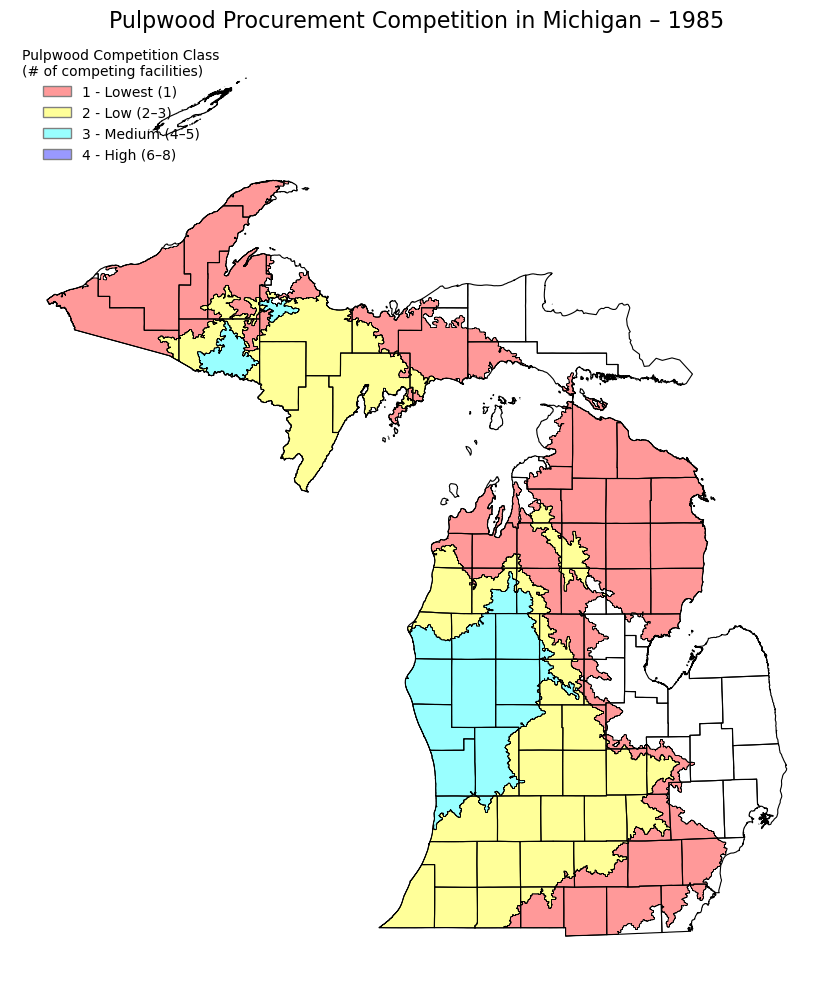

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data"
michigan_fp = f"{base_path}\\Counties_(v17a).shp"
hotspot_fp = f"{base_path}\\pulpwood_hotspots_1985.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# --- Reproject if necessary ---
if gdf_michigan.crs != gdf_hotspots.crs:
    gdf_hotspots = gdf_hotspots.to_crs(gdf_michigan.crs)

# --- Define colors for each unique label ---
label_colors = {
    "1 - Lowest (1985)": "#ff9999",
    "2 - Low (1985)": "#ffff99",
    "3 - Medium (1985)": "#99ffff",
    "4 - High (1985)": "#9999ff"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each class with the assigned color
for label, color in label_colors.items():
    subset = gdf_hotspots[gdf_hotspots["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5, label=label)

# Plot Michigan counties
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# --- Legend ---
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='grey', label='1 - Lowest (1)'),
    Patch(facecolor='#ffff99', edgecolor='grey', label='2 - Low (2–3)'),
    Patch(facecolor='#99ffff', edgecolor='grey', label='3 - Medium (4–5)'),
    Patch(facecolor='#9999ff', edgecolor='grey', label='4 - High (6–8)'),
]

ax.legend(
    handles=legend_elements,
    title='Pulpwood Competition Class\n(# of competing facilities)',
    loc='upper left',
    frameon=False
)

plt.title("Pulpwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


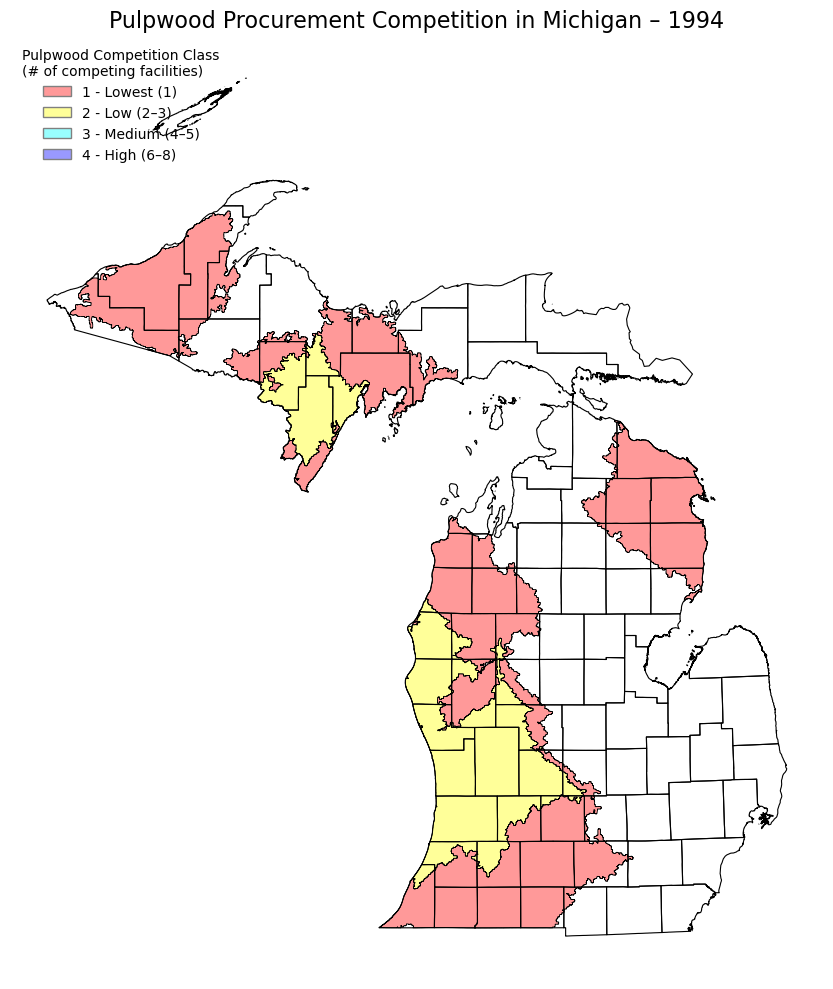

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Pulp\Pulp new classes\SHPs\competition_classes_1994.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# --- Reproject if necessary ---
if gdf_michigan.crs != gdf_hotspots.crs:
    gdf_hotspots = gdf_hotspots.to_crs(gdf_michigan.crs)

# --- Define colors based on class_val ---
class_colors = {
    1: "#ff9999",  # Lowest
    2: "#ffff99",  # Low
    3: "#99ffff",  # Medium
    4: "#9999ff"   # High
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each class with corresponding color
for class_val, color in class_colors.items():
    subset = gdf_hotspots[gdf_hotspots["class_val"] == class_val]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Plot Michigan counties
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# --- Legend ---
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='grey', label='1 - Lowest (1)'),
    Patch(facecolor='#ffff99', edgecolor='grey', label='2 - Low (2–3)'),
    Patch(facecolor='#99ffff', edgecolor='grey', label='3 - Medium (4–5)'),
    Patch(facecolor='#9999ff', edgecolor='grey', label='4 - High (6–8)')
]

ax.legend(
    handles=legend_elements,
    title='Pulpwood Competition Class\n(# of competing facilities)',
    loc='upper left',
    frameon=False
)

plt.title("Pulpwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


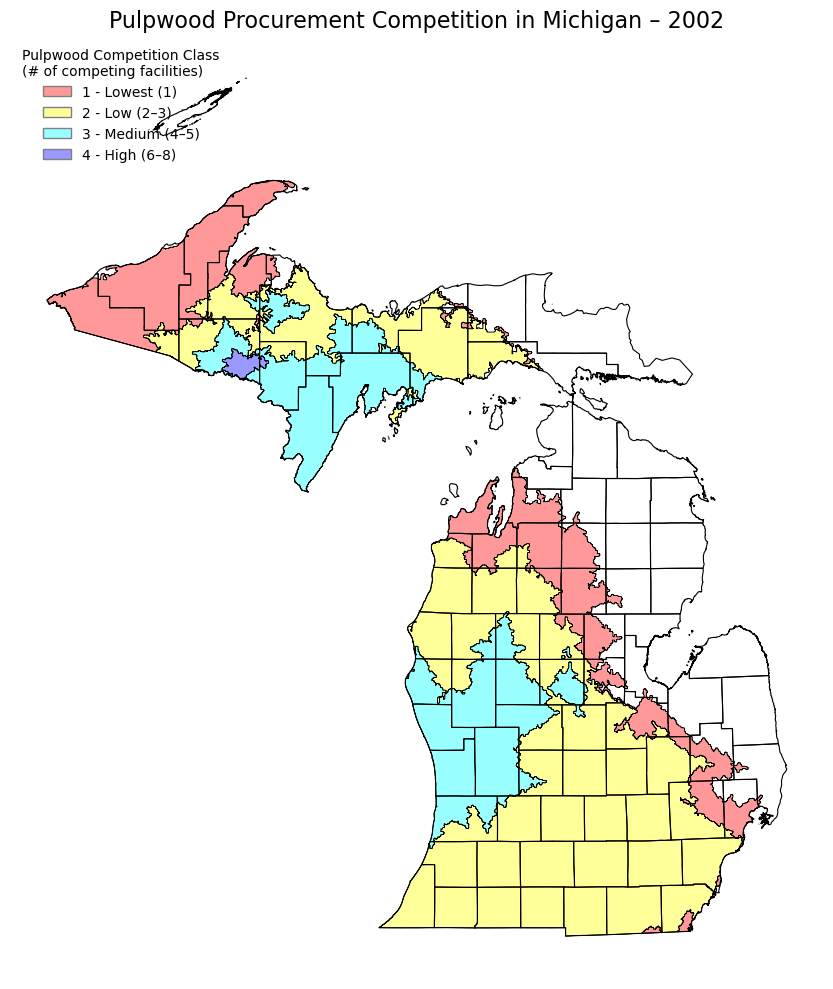

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data"
michigan_fp = f"{base_path}\\Counties_(v17a).shp"
hotspot_fp = f"{base_path}\\pulpwood_hotspots_2002.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# --- Reproject if necessary ---
if gdf_michigan.crs != gdf_hotspots.crs:
    gdf_hotspots = gdf_hotspots.to_crs(gdf_michigan.crs)

# --- Define colors for each unique label ---
label_colors = {
    "1 - Lowest (2002)": "#ff9999",
    "2 - Low (2002)": "#ffff99",
    "3 - Medium (2002)": "#99ffff",
    "4 - High (2002)": "#9999ff"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each class with the assigned color
for label, color in label_colors.items():
    subset = gdf_hotspots[gdf_hotspots["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5, label=label)

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# --- Legend ---
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='grey', label='1 - Lowest (1)'),
    Patch(facecolor='#ffff99', edgecolor='grey', label='2 - Low (2–3)'),
    Patch(facecolor='#99ffff', edgecolor='grey', label='3 - Medium (4–5)'),
    Patch(facecolor='#9999ff', edgecolor='grey', label='4 - High (6–8)')
]

ax.legend(
    handles=legend_elements,
    title='Pulpwood Competition Class\n(# of competing facilities)',
    loc='upper left',
    frameon=False
)

plt.title("Pulpwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


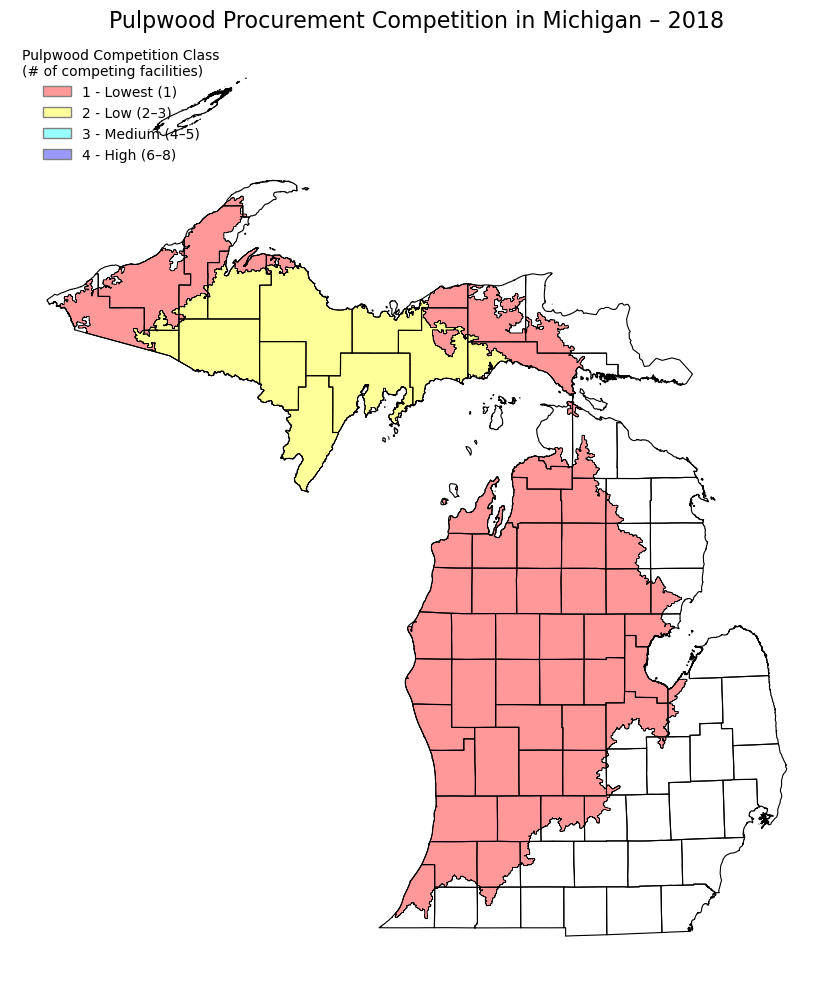

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data"
michigan_fp = f"{base_path}\\Counties_(v17a).shp"
hotspot_fp = f"{base_path}\\pulpwood_hotspots_2018.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# --- Reproject if needed ---
if gdf_michigan.crs != gdf_hotspots.crs:
    gdf_hotspots = gdf_hotspots.to_crs(gdf_michigan.crs)

# --- Color mapping based on 'label' ---
label_colors = {
    "1 - Lowest (2018)": "#ff9999",
    "2 - Low (2018)": "#ffff99",
    "3 - Medium (2018)": "#99ffff",
    "4 - High (2018)": "#9999ff"  # Add this only if present in data
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each class with its color
for label, color in label_colors.items():
    subset = gdf_hotspots[gdf_hotspots["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5, label=label)

# Plot Michigan counties
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# --- Legend ---
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='grey', label='1 - Lowest (1)'),
    Patch(facecolor='#ffff99', edgecolor='grey', label='2 - Low (2–3)'),
    Patch(facecolor='#99ffff', edgecolor='grey', label='3 - Medium (4–5)'),
    Patch(facecolor='#9999ff', edgecolor='grey', label='4 - High (6–8)')
]

ax.legend(
    handles=legend_elements,
    title='Pulpwood Competition Class\n(# of competing facilities)',
    loc='upper left',
    frameon=False
)

plt.title("Pulpwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


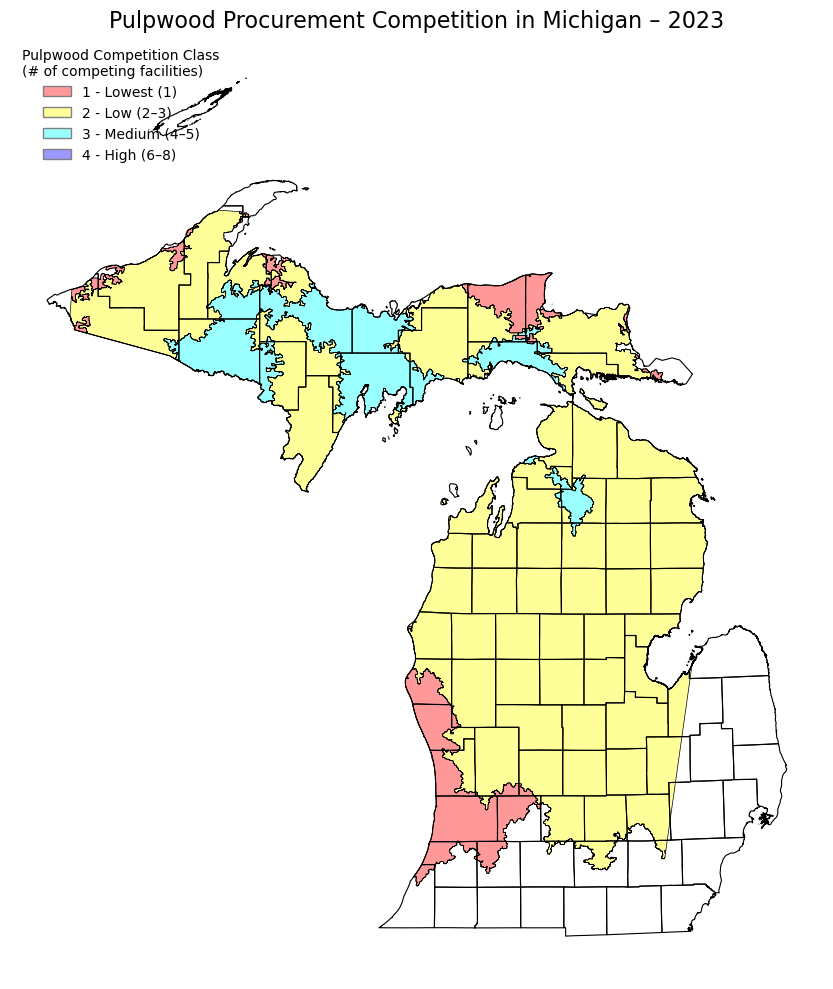

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data"
michigan_fp = f"{base_path}\\Counties_(v17a).shp"
hotspot_fp = f"{base_path}\\pulpwood_hotspots_2023.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# --- Reproject if necessary ---
if gdf_michigan.crs != gdf_hotspots.crs:
    gdf_hotspots = gdf_hotspots.to_crs(gdf_michigan.crs)

# --- Define colors for each unique label ---
label_colors = {
    "1 - Lowest (2023)": "#ff9999",
    "2 - Low (2023)": "#ffff99",
    "3 - Medium (2023)": "#99ffff"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each class with the assigned color
for label, color in label_colors.items():
    subset = gdf_hotspots[gdf_hotspots["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5, label=label)

# Plot Michigan counties
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# --- Legend ---
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='grey', label='1 - Lowest (1)'),
    Patch(facecolor='#ffff99', edgecolor='grey', label='2 - Low (2–3)'),
    Patch(facecolor='#99ffff', edgecolor='grey', label='3 - Medium (4–5)'),
    Patch(facecolor='#9999ff', edgecolor='grey', label='4 - High (6–8)'),
]


ax.legend(
    handles=legend_elements,
    title='Pulpwood Competition Class\n(# of competing facilities)',
    loc='upper left',
    frameon=False
)

plt.title("Pulpwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


# Softwood Sawlogs 

In [11]:
print(gdf_hotspot.columns)


Index(['Id', 'gridcode', 'geometry'], dtype='object')


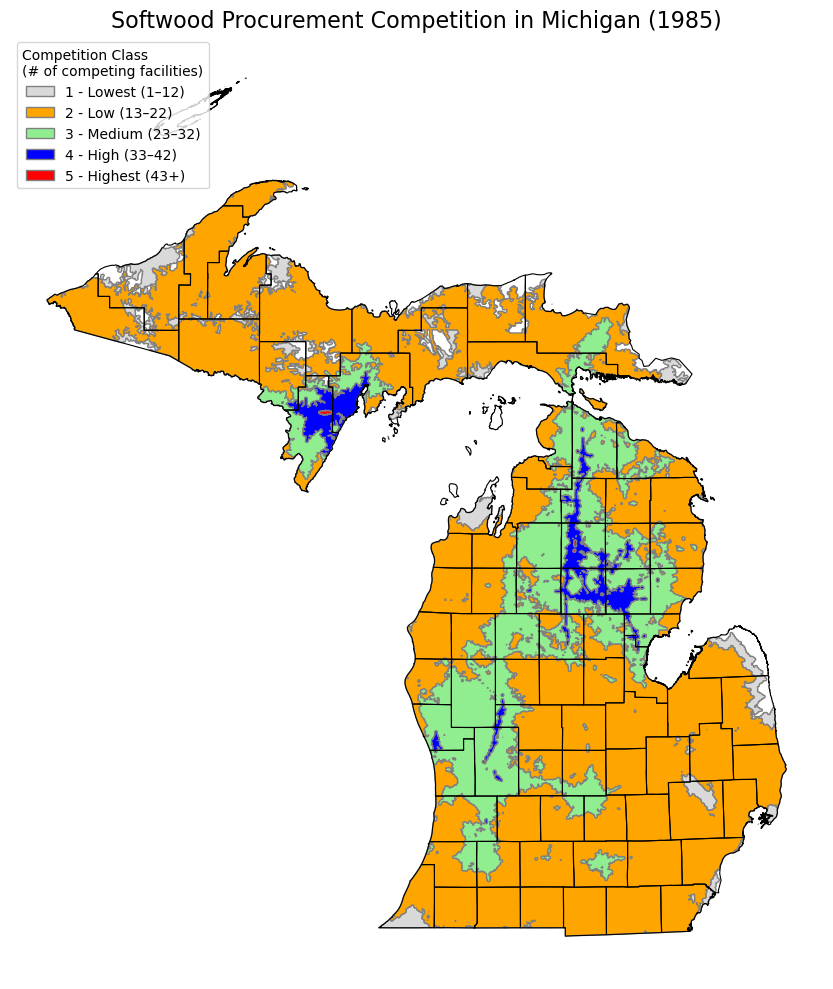

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\softwood_hotspots_1985.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspot = gpd.read_file(hotspot_fp)

# --- Reproject hotspot if needed ---
if gdf_michigan.crs != gdf_hotspot.crs:
    gdf_hotspot = gdf_hotspot.to_crs(gdf_michigan.crs)

# --- Color mapping based on `label` ---
label_color_map = {
    "1 - Lowest (1985)": "#D9D9D9",   # Light gray
    "2 - Low (1985)": "#FFA500",      # Orange
    "3 - Medium (1985)": "#90EE90",   # Light green
    "4 - High (1985)": "#0000FF",     # Blue
    "5 - Highest (1985)": "#FF0000"   # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot by label
for label, color in label_color_map.items():
    subset = gdf_hotspot[gdf_hotspot['label'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Custom Legend ---
legend_elements = [
    Patch(facecolor='#D9D9D9', edgecolor='grey', label='1 - Lowest (1–12)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='2 - Low (13–22)'),
    Patch(facecolor='#90EE90', edgecolor='grey', label='3 - Medium (23–32)'),
    Patch(facecolor='#0000FF', edgecolor='grey', label='4 - High (33–42)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (43+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

# --- Final touches ---
plt.title("Softwood Procurement Competition in Michigan (1985)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


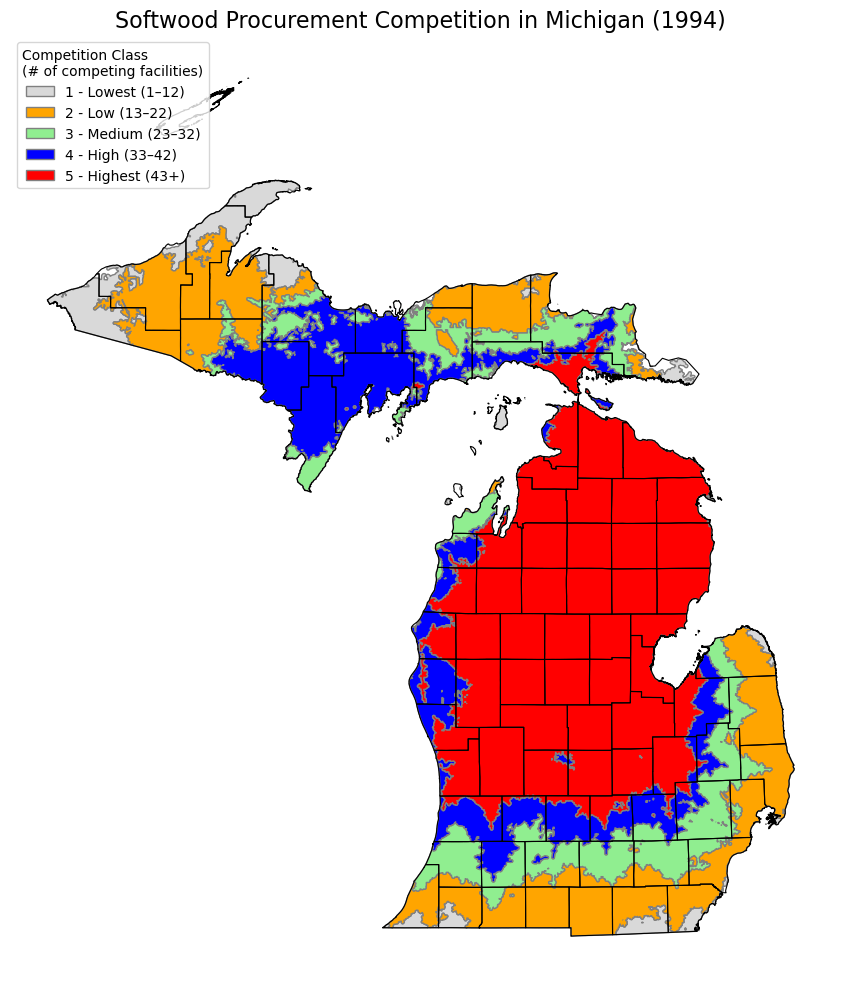

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\softwood_hotspots_1994.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspot = gpd.read_file(hotspot_fp)

# --- Reproject if needed ---
if gdf_michigan.crs != gdf_hotspot.crs:
    gdf_hotspot = gdf_hotspot.to_crs(gdf_michigan.crs)

# --- Color mapping based on `label` ---
label_color_map = {
    "1 - Lowest (1994)": "#D9D9D9",   # Light gray
    "2 - Low (1994)": "#FFA500",      # Orange
    "3 - Medium (1994)": "#90EE90",   # Light green
    "4 - High (1994)": "#0000FF",     # Blue
    "5 - Highest (1994)": "#FF0000"   # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot by label
for label, color in label_color_map.items():
    subset = gdf_hotspot[gdf_hotspot['label'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Custom Legend ---
legend_elements = [
    Patch(facecolor='#D9D9D9', edgecolor='grey', label='1 - Lowest (1–12)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='2 - Low (13–22)'),
    Patch(facecolor='#90EE90', edgecolor='grey', label='3 - Medium (23–32)'),
    Patch(facecolor='#0000FF', edgecolor='grey', label='4 - High (33–42)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (43+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

# --- Final touches ---
plt.title("Softwood Procurement Competition in Michigan (1994)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


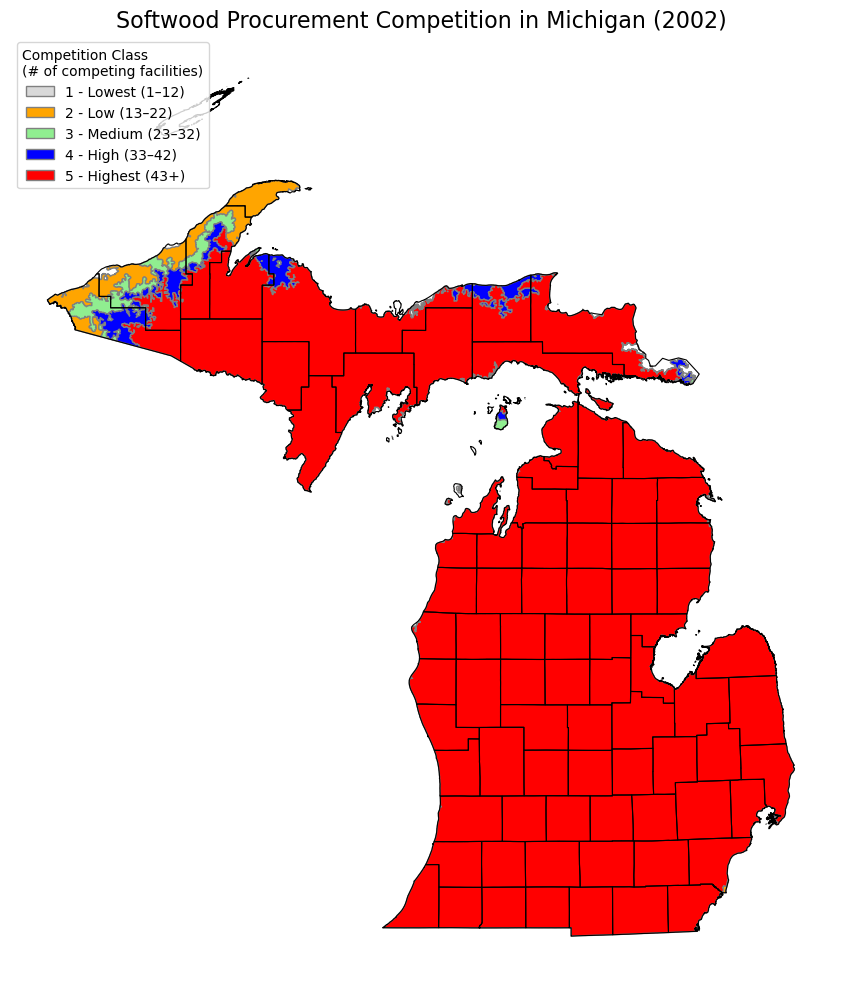

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\softwood_hotspots_2002.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspot = gpd.read_file(hotspot_fp)

# --- Reproject if needed ---
if gdf_michigan.crs != gdf_hotspot.crs:
    gdf_hotspot = gdf_hotspot.to_crs(gdf_michigan.crs)

# --- Color mapping based on `label` ---
label_color_map = {
    "1 - Lowest (2002)": "#D9D9D9",   # Light gray
    "2 - Low (2002)": "#FFA500",      # Orange
    "3 - Medium (2002)": "#90EE90",   # Light green
    "4 - High (2002)": "#0000FF",     # Blue
    "5 - Highest (2002)": "#FF0000"   # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each class
for label, color in label_color_map.items():
    subset = gdf_hotspot[gdf_hotspot['label'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor='#D9D9D9', edgecolor='grey', label='1 - Lowest (1–12)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='2 - Low (13–22)'),
    Patch(facecolor='#90EE90', edgecolor='grey', label='3 - Medium (23–32)'),
    Patch(facecolor='#0000FF', edgecolor='grey', label='4 - High (33–42)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (43+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

# --- Final layout ---
plt.title("Softwood Procurement Competition in Michigan (2002)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


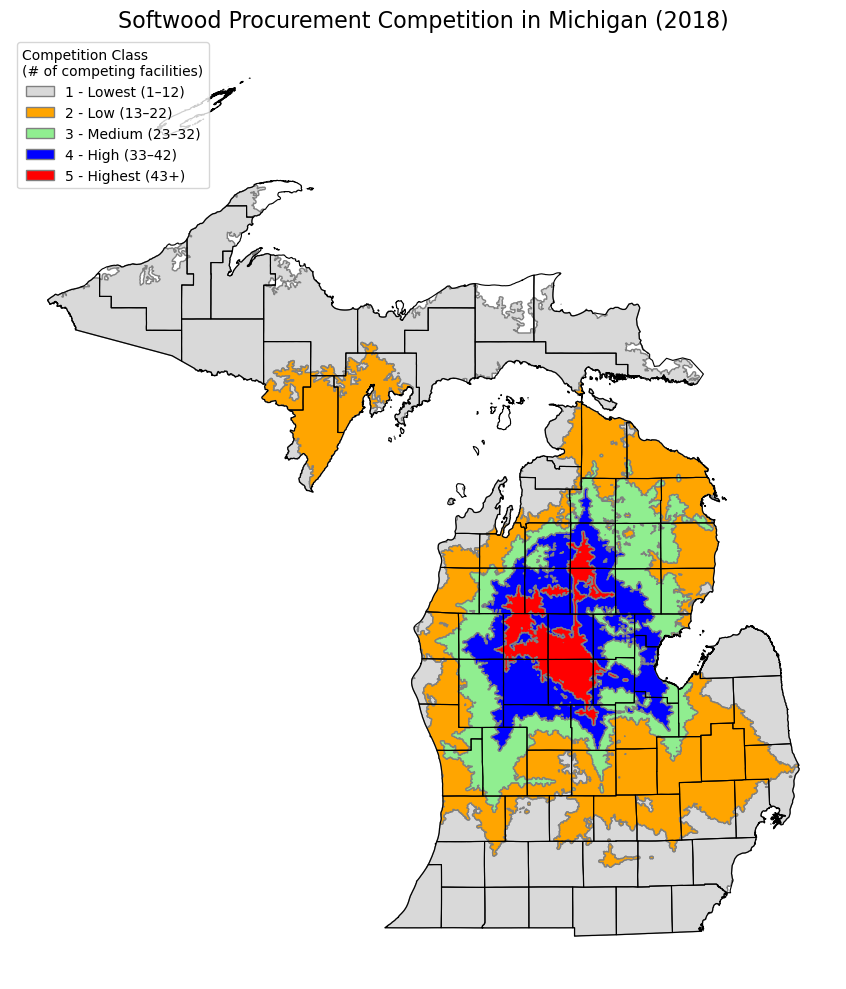

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\softwood_hotspots_2018.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspot = gpd.read_file(hotspot_fp)

# --- Reproject if needed ---
if gdf_michigan.crs != gdf_hotspot.crs:
    gdf_hotspot = gdf_hotspot.to_crs(gdf_michigan.crs)

# --- Color mapping based on `label` ---
label_color_map = {
    "1 - Lowest (2018)": "#D9D9D9",   # Light gray
    "2 - Low (2018)": "#FFA500",      # Orange
    "3 - Medium (2018)": "#90EE90",   # Light green
    "4 - High (2018)": "#0000FF",     # Blue
    "5 - Highest (2018)": "#FF0000"   # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each class
for label, color in label_color_map.items():
    subset = gdf_hotspot[gdf_hotspot['label'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor='#D9D9D9', edgecolor='grey', label='1 - Lowest (1–12)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='2 - Low (13–22)'),
    Patch(facecolor='#90EE90', edgecolor='grey', label='3 - Medium (23–32)'),
    Patch(facecolor='#0000FF', edgecolor='grey', label='4 - High (33–42)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (43+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

# --- Final layout ---
plt.title("Softwood Procurement Competition in Michigan (2018)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


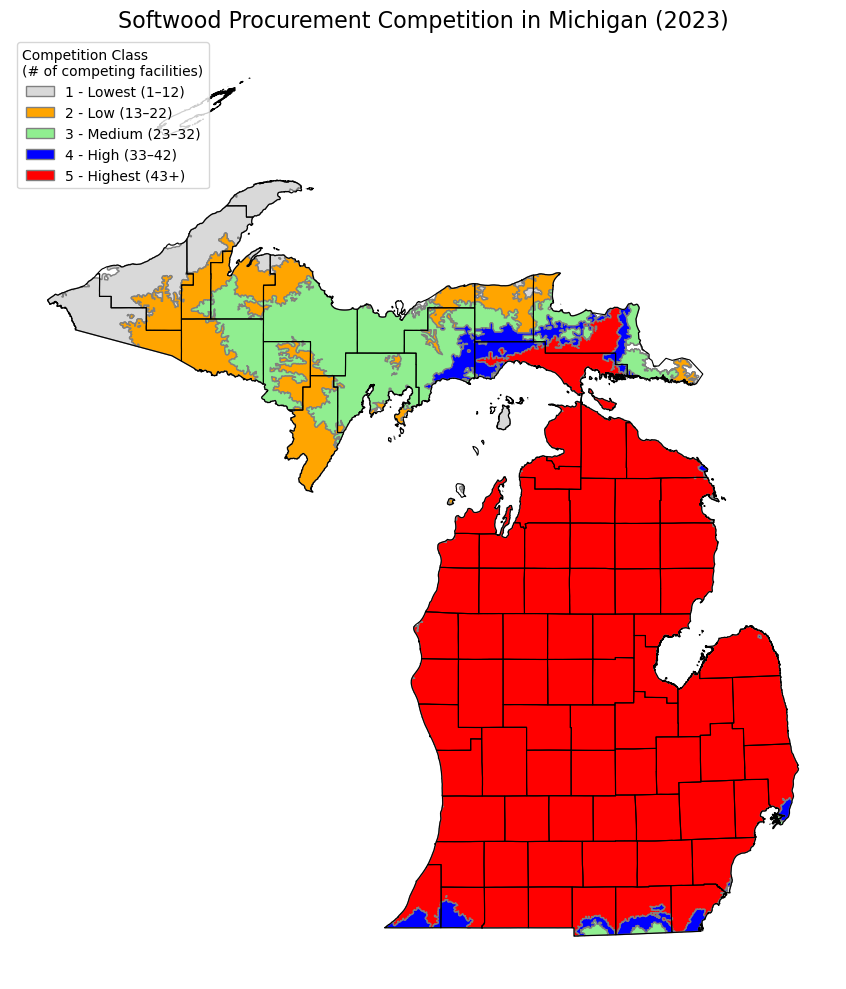

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hotspot_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\softwood_hotspots_2023.shp"

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspot = gpd.read_file(hotspot_fp)

# --- Reproject if needed ---
if gdf_michigan.crs != gdf_hotspot.crs:
    gdf_hotspot = gdf_hotspot.to_crs(gdf_michigan.crs)

# --- Color mapping based on `label` ---
label_color_map = {
    "1 - Lowest (2023)": "#D9D9D9",   # Light gray
    "2 - Low (2023)": "#FFA500",      # Orange
    "3 - Medium (2023)": "#90EE90",   # Light green
    "4 - High (2023)": "#0000FF",     # Blue
    "5 - Highest (2023)": "#FF0000"   # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each class
for label, color in label_color_map.items():
    subset = gdf_hotspot[gdf_hotspot['label'] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor='#D9D9D9', edgecolor='grey', label='1 - Lowest (1–12)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='2 - Low (13–22)'),
    Patch(facecolor='#90EE90', edgecolor='grey', label='3 - Medium (23–32)'),
    Patch(facecolor='#0000FF', edgecolor='grey', label='4 - High (33–42)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (43+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

# --- Final layout ---
plt.title("Softwood Procurement Competition in Michigan (2023)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


# Hardwood Sawlogs

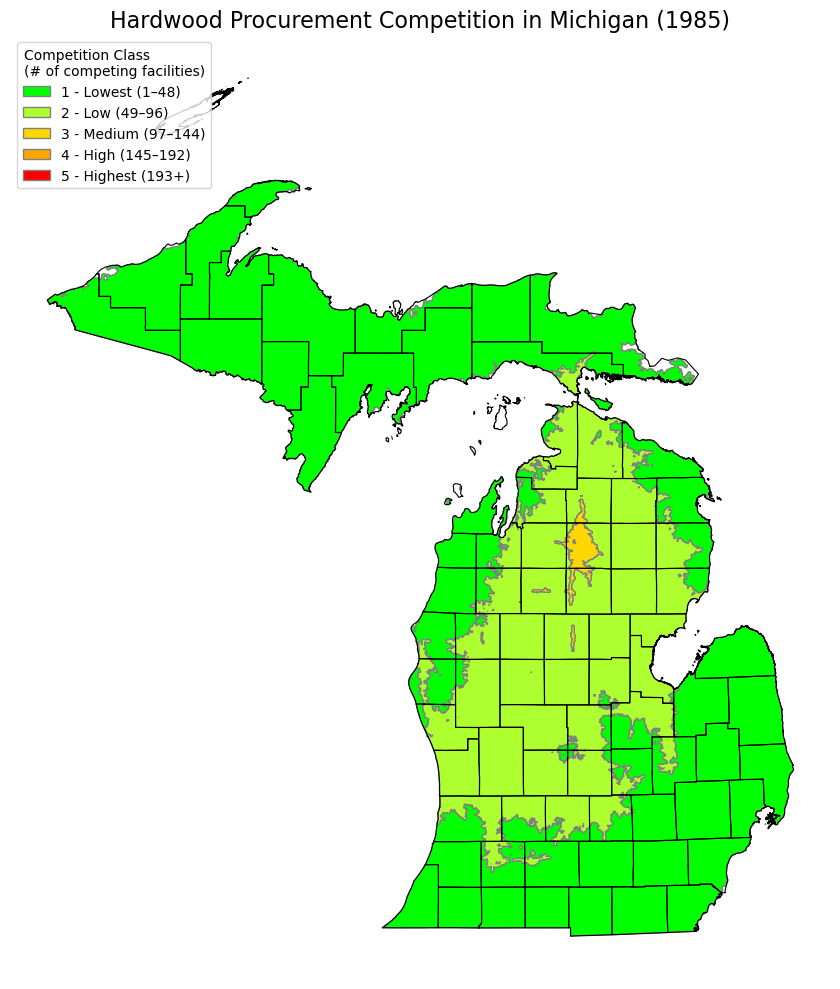

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hardwood_1985_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\hardwood_hotspots_1985.shp"

# --- Load data ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_1985 = gpd.read_file(hardwood_1985_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_michigan.crs:
    gdf_1985 = gdf_1985.to_crs(gdf_michigan.crs)

# --- Color map (based on label order) ---
color_map = {
    "1 - Lowest (1985)": "#00FF00",    # Bright Green
    "2 - Low (1985)": "#ADFF2F",       # Green Yellow
    "3 - Medium (1985)": "#FFD700",    # Gold
    "4 - High (1985)": "#FFA500",      # Orange
    "5 - Highest (1985)": "#FF0000"    # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each level
for label, color in color_map.items():
    subset = gdf_1985[gdf_1985["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Manual legend ---
legend_elements = [
    Patch(facecolor='#00FF00', edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor='#ADFF2F', edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor='#FFD700', edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (193+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

plt.title("Hardwood Procurement Competition in Michigan (1985)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


In [34]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# ✅ UPDATED paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots shpfile July 2025\Data\lulc2001.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots shpfile July 2025\Data\hardwood_hotspots_1985.shp"

# Define the forest values to be included
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        for feature in shp:
            # 🔁 Use the "label" field instead of polygon ID
            polygon_label = feature["properties"].get("label", "unknown")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon '{polygon_label}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]

            if nodata is not None:
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon '{polygon_label}' has a forest area of {forest_area_acres:.2f} acres.")


Polygon '1 - Lowest (1985)' has a forest area of 9852057.22 acres.
Polygon '2 - Low (1985)' has a forest area of 5520890.76 acres.
Polygon '3 - Medium (1985)' has a forest area of 189853.51 acres.


In [36]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# ✅ Updated raster path
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots shpfile July 2025\Data\forest_cover_2019.tif"

# ✅ Shapefile path remains the same
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots shpfile July 2025\Data\hardwood_hotspots_1985.shp"

# Forest type mapping (from the attribute table)
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Open the raster file
with rasterio.open(clipped_raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105

    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for feature in shapefile:
            polygon_label = feature["properties"].get("label", "unknown")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon '{polygon_label}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type, None): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
            }
            forest_type_areas_acres = {
                name: area for name, area in forest_type_areas_acres.items() if name is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"Polygon '{polygon_label}' has a forest area of {total_area_acres:.2f} acres.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print()


Polygon '1 - Lowest (1985)' has a forest area of 12416655.59 acres.
   White/Red/Jack Pine Group: 1070783.19 acres
   Spruce/Fir Group: 2727544.99 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Pine Group: 30.89 acres
   Oak/Hickory Group: 147104.70 acres
   Elm/Ash/Cottonwood Group: 174209.03 acres
   Maple/Beech/Birch Group: 4006128.04 acres
   Aspen/Birch Group: 4290715.78 acres

Polygon '2 - Low (1985)' has a forest area of 6086072.60 acres.
   White/Red/Jack Pine Group: 1269038.62 acres
   Spruce/Fir Group: 453422.23 acres
   Oak/Hickory Group: 7104.27 acres
   Elm/Ash/Cottonwood Group: 5389.98 acres
   Maple/Beech/Birch Group: 6733.61 acres
   Aspen/Birch Group: 4344383.89 acres

Polygon '3 - Medium (1985)' has a forest area of 218409.93 acres.
   White/Red/Jack Pine Group: 82270.52 acres
   Spruce/Fir Group: 18100.44 acres
   Aspen/Birch Group: 118038.97 acres



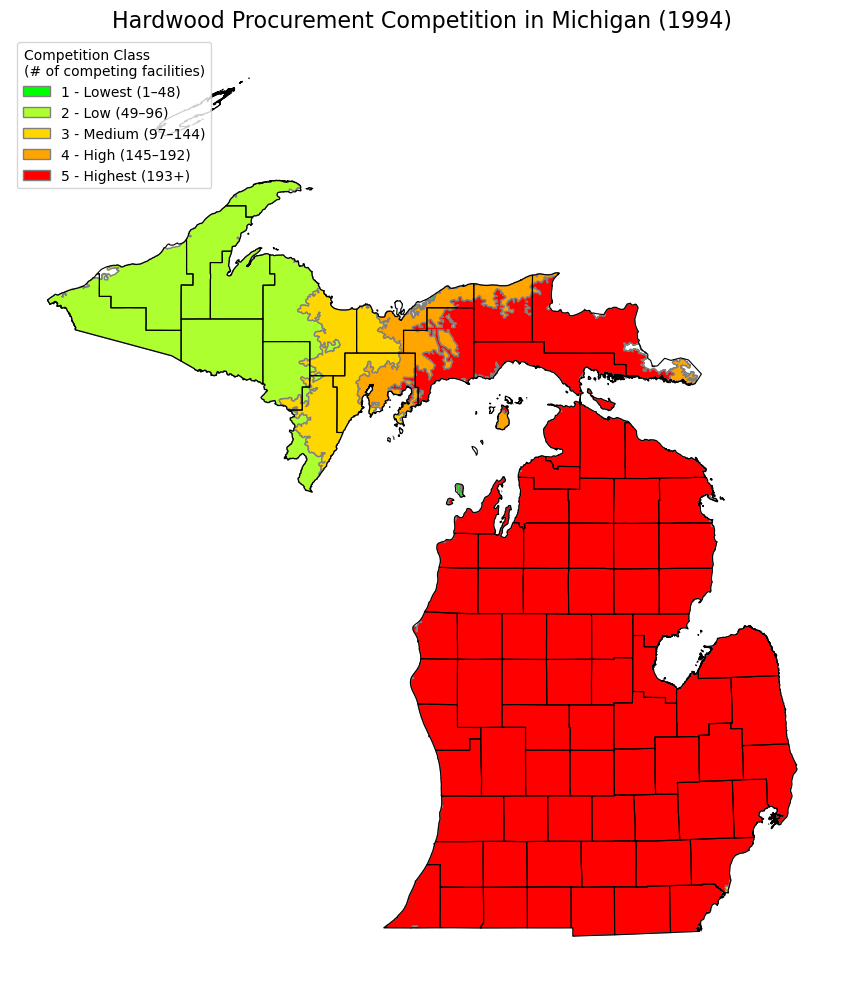

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hardwood_1994_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\hardwood_hotspots_1994.shp"

# --- Load data ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_1994 = gpd.read_file(hardwood_1994_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_michigan.crs:
    gdf_1994 = gdf_1994.to_crs(gdf_michigan.crs)

# --- Color map ---
color_map = {
    "1 - Lowest (1994)": "#00FF00",    # Bright Green
    "2 - Low (1994)": "#ADFF2F",       # Green Yellow
    "3 - Medium (1994)": "#FFD700",    # Gold
    "4 - High (1994)": "#FFA500",      # Orange
    "5 - Highest (1994)": "#FF0000"    # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each level
for label, color in color_map.items():
    subset = gdf_1994[gdf_1994["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Manual legend ---
legend_elements = [
    Patch(facecolor='#00FF00', edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor='#ADFF2F', edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor='#FFD700', edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (193+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

plt.title("Hardwood Procurement Competition in Michigan (1994)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


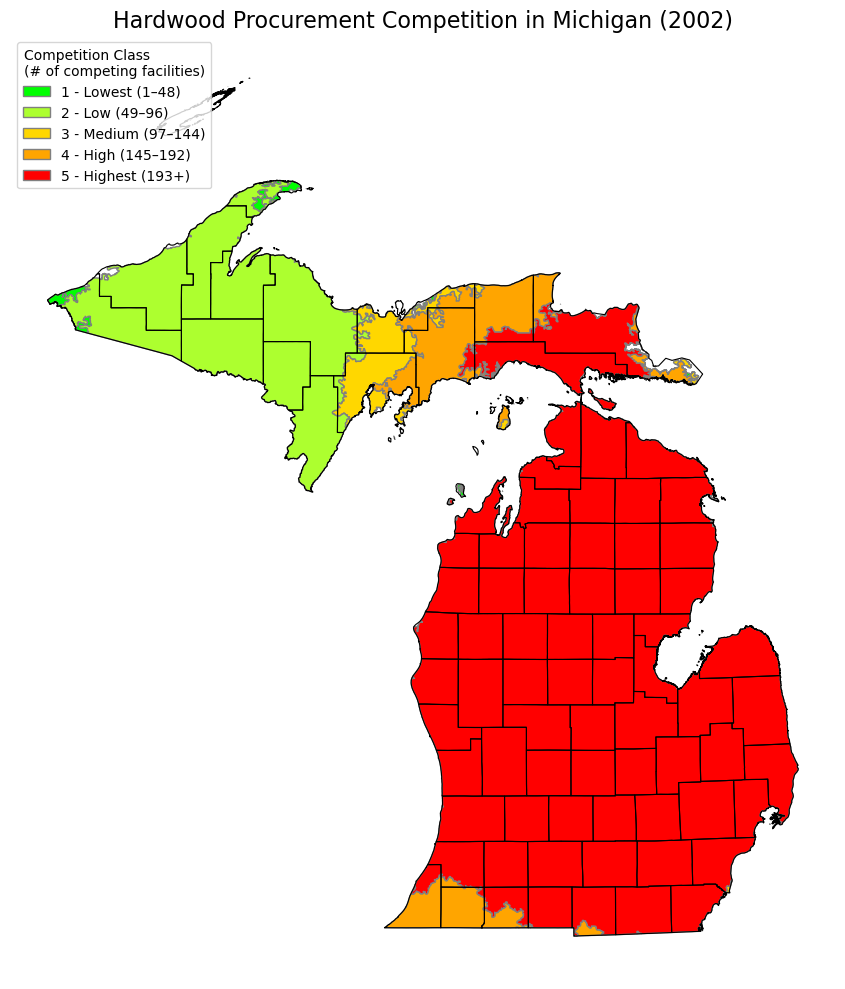

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hardwood_2002_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\hardwood_hotspots_2002.shp"

# --- Load data ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_2002 = gpd.read_file(hardwood_2002_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_michigan.crs:
    gdf_2002 = gdf_2002.to_crs(gdf_michigan.crs)

# --- Color map ---
color_map = {
    "1 - Lowest (2002)": "#00FF00",    # Bright Green
    "2 - Low (2002)": "#ADFF2F",       # Green Yellow
    "3 - Medium (2002)": "#FFD700",    # Gold
    "4 - High (2002)": "#FFA500",      # Orange
    "5 - Highest (2002)": "#FF0000"    # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each level
for label, color in color_map.items():
    subset = gdf_2002[gdf_2002["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Manual legend ---
legend_elements = [
    Patch(facecolor='#00FF00', edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor='#ADFF2F', edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor='#FFD700', edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (193+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

plt.title("Hardwood Procurement Competition in Michigan (2002)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


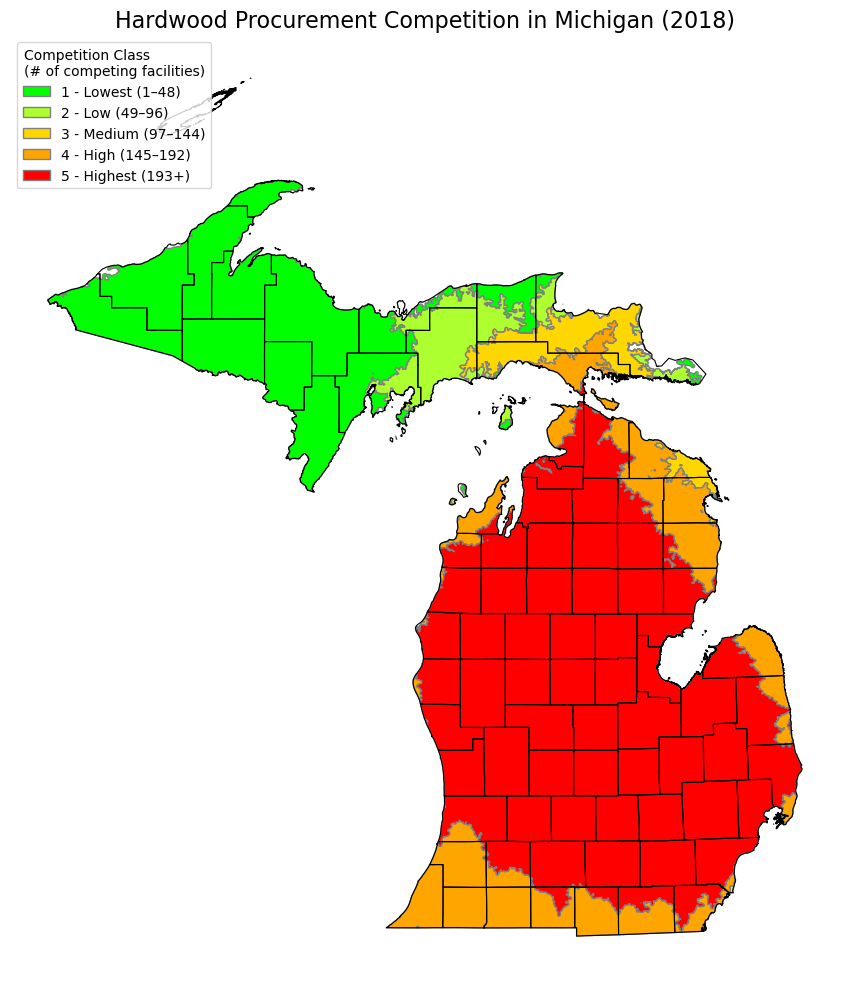

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hardwood_2018_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\hardwood_hotspots_2018.shp"

# --- Load data ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_2018 = gpd.read_file(hardwood_2018_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_michigan.crs:
    gdf_2018 = gdf_2018.to_crs(gdf_michigan.crs)

# --- Color map ---
color_map = {
    "1 - Lowest (2018)": "#00FF00",    # Bright Green
    "2 - Low (2018)": "#ADFF2F",       # Green Yellow
    "3 - Medium (2018)": "#FFD700",    # Gold
    "4 - High (2018)": "#FFA500",      # Orange
    "5 - Highest (2018)": "#FF0000"    # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each level
for label, color in color_map.items():
    subset = gdf_2018[gdf_2018["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Manual legend ---
legend_elements = [
    Patch(facecolor='#00FF00', edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor='#ADFF2F', edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor='#FFD700', edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (193+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

plt.title("Hardwood Procurement Competition in Michigan (2018)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


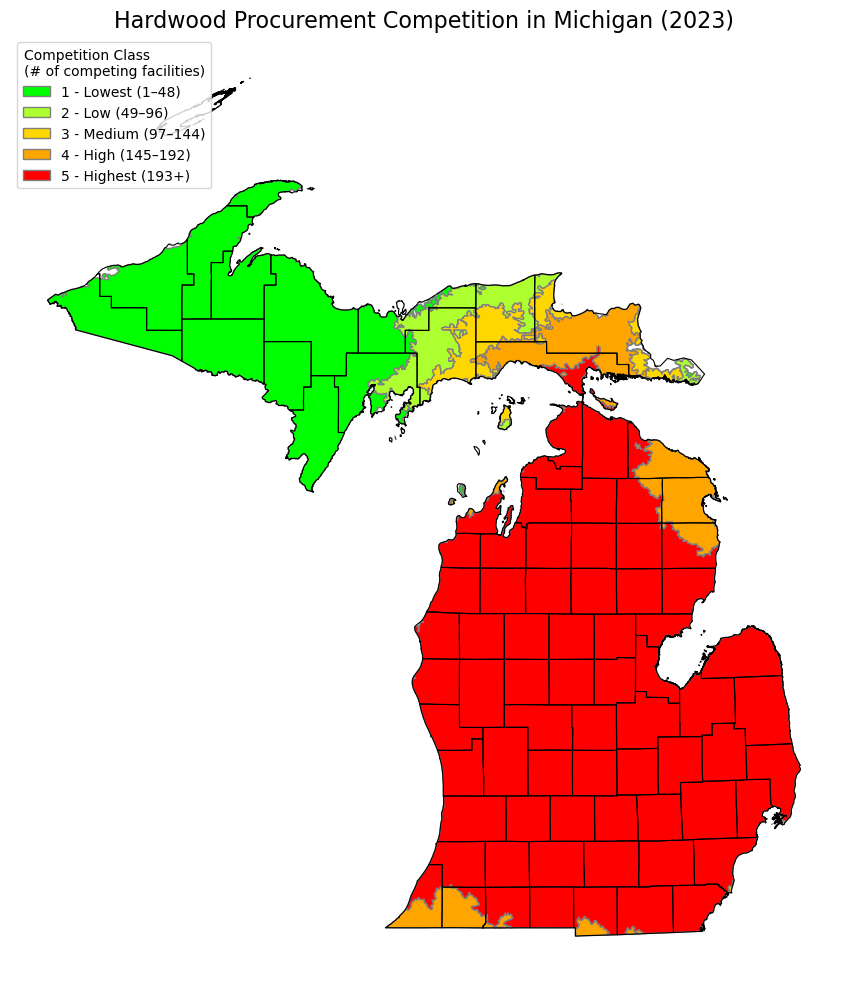

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
hardwood_2023_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\hardwood_hotspots_2023.shp"

# --- Load data ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_2023 = gpd.read_file(hardwood_2023_fp)

# --- Reproject if needed ---
if gdf_2023.crs != gdf_michigan.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_michigan.crs)

# --- Color map ---
color_map = {
    "1 - Lowest (2023)": "#00FF00",    # Bright Green
    "2 - Low (2023)": "#ADFF2F",       # Green Yellow
    "3 - Medium (2023)": "#FFD700",    # Gold
    "4 - High (2023)": "#FFA500",      # Orange
    "5 - Highest (2023)": "#FF0000"    # Red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_michigan.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each level
for label, color in color_map.items():
    subset = gdf_2023[gdf_2023["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Manual legend ---
legend_elements = [
    Patch(facecolor='#00FF00', edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor='#ADFF2F', edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor='#FFD700', edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor='#FFA500', edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor='#FF0000', edgecolor='grey', label='5 - Highest (193+)')
]

ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper left', frameon=True)

plt.title("Hardwood Procurement Competition in Michigan (2023)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


# Biomass 

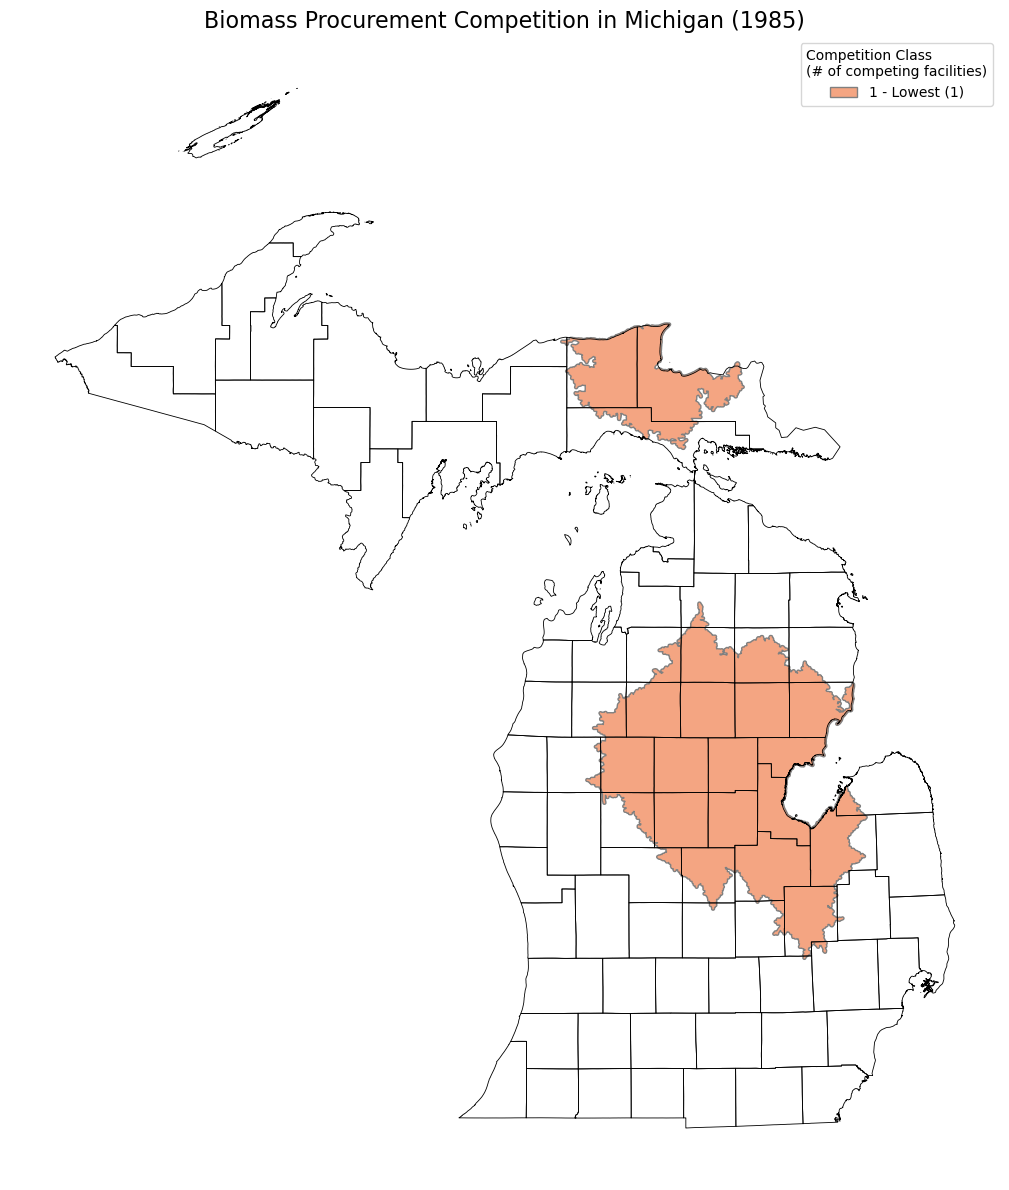

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
biomass_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\biomass_hotspots_1985.shp"

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Define color map (only for available class) ---
color_map = {
    "1 - Lowest (1985)": "#F4A582"  # light reddish
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 12))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.6)

# Plot only the available biomass class
gdf_bio.plot(ax=ax, color=color_map["1 - Lowest (1985)"], edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)")
]
ax.legend(handles=legend_elements, title="Competition Class\n(# of competing facilities)", loc='upper right')

plt.title("Biomass Procurement Competition in Michigan (1985)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


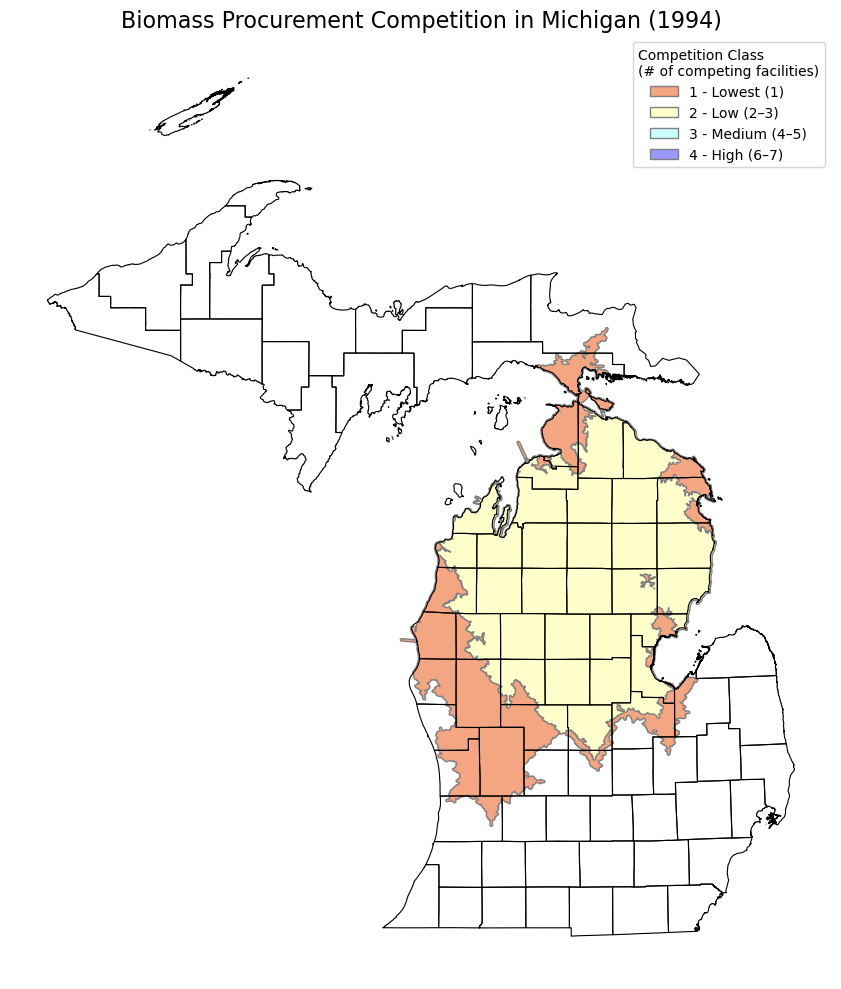

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
biomass_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\biomass_hotspots_1994.shp"

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Define color map based on competition class ---
color_map = {
    "1 - Lowest (1994)": "#F4A582",  # light red
    "2 - Low (1994)": "#FFFFCC",     # light yellow
    "3 - Medium (1994)": "#CCFFFF",  # light cyan
    "4 - High (1994)": "#9999FF",    # light purple
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each competition level
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(handles=legend_elements,
          title="Competition Class\n(# of competing facilities)",
          loc='upper right', frameon=True)

plt.title("Biomass Procurement Competition in Michigan (1994)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


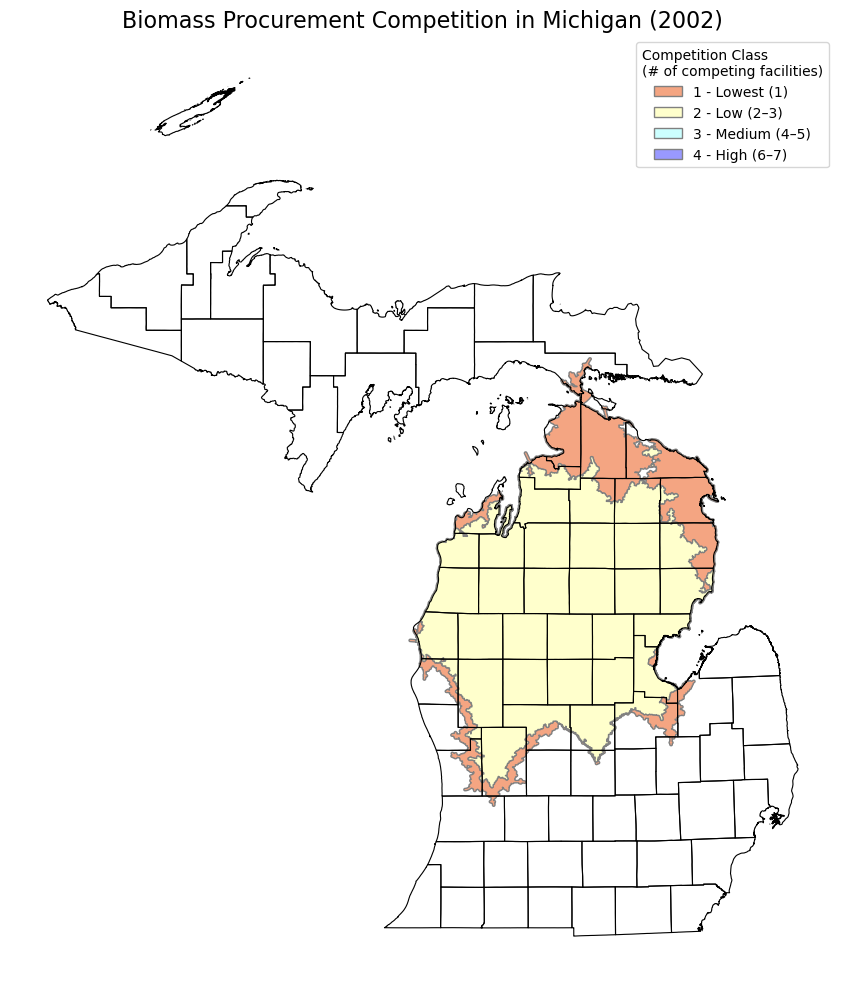

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
biomass_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\biomass_hotspots_2002.shp"

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Define color map based on label ---
color_map = {
    "1 - Lowest (2002)": "#F4A582",
    "2 - Low (2002)": "#FFFFCC",
    "3 - Medium (2002)": "#CCFFFF",
    "4 - High (2002)": "#9999FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each competition level
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(handles=legend_elements,
          title="Competition Class\n(# of competing facilities)",
          loc='upper right', frameon=True)

plt.title("Biomass Procurement Competition in Michigan (2002)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


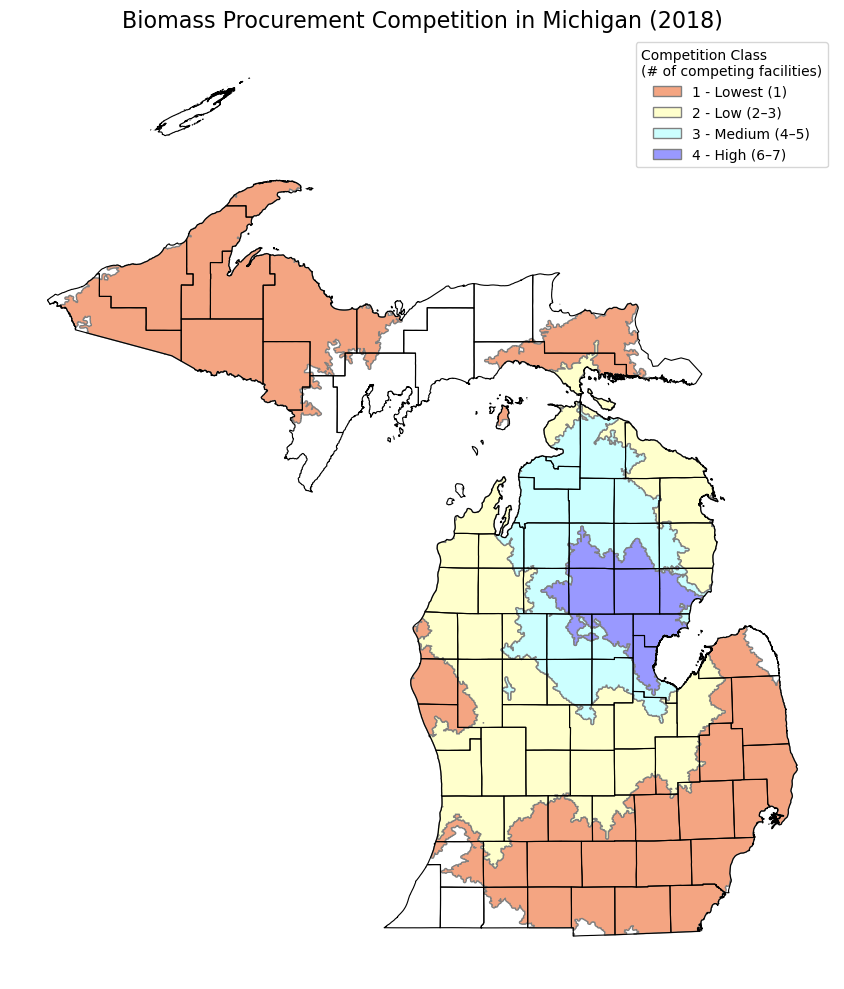

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
biomass_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\biomass_hotspots_2018.shp"

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Define color map ---
color_map = {
    "1 - Lowest (2018)": "#F4A582",
    "2 - Low (2018)": "#FFFFCC",
    "3 - Medium (2018)": "#CCFFFF",
    "4 - High (2018)": "#9999FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each label
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(handles=legend_elements,
          title="Competition Class\n(# of competing facilities)",
          loc='upper right', frameon=True)

plt.title("Biomass Procurement Competition in Michigan (2018)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


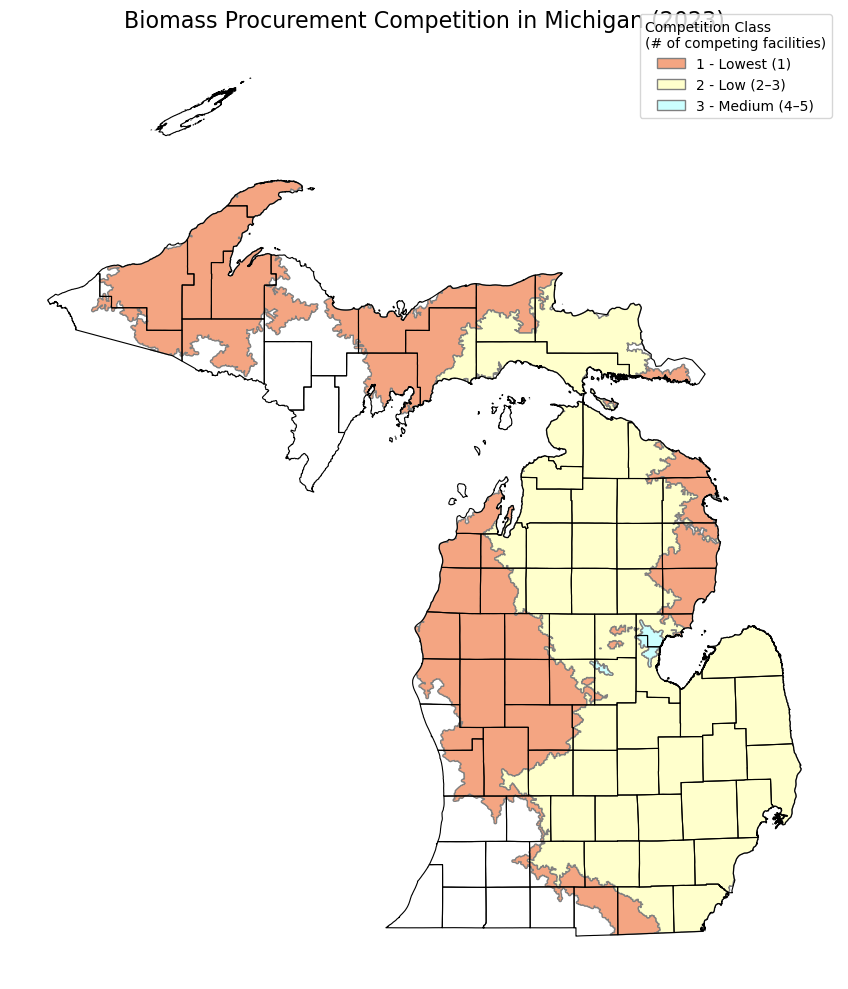

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- File paths ---
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
biomass_fp = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Github\Khanal_MSc_Thesis_MSU\Khanal_MSU_project_Hotspot_area_1980s-2020s\Data\biomass_hotspots_2023.shp"

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Define color map ---
color_map = {
    "1 - Lowest (2023)": "#F4A582",
    "2 - Low (2023)": "#FFFFCC",
    "3 - Medium (2023)": "#CCFFFF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each competition level
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='grey')

# --- Legend ---
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)")
]

ax.legend(handles=legend_elements,
          title="Competition Class\n(# of competing facilities)",
          loc='upper right', frameon=True, bbox_to_anchor=(1, 1.03))

plt.title("Biomass Procurement Competition in Michigan (2023)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


# Forest Area for Competition Hotspots

**Major Calulations of the AREA**

**2018 Hardwood**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Path to the clipped raster
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Randoms\clipped_forestgroup.tif"

# Path to the shapefile containing the 5 polygons
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2018\hard\hard18.shp"

# Forest type mapping (from the attribute table)
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Open the raster file
with rasterio.open(clipped_raster_path) as src:
    # Get pixel size and compute area of one pixel in square meters
    pixel_width = src.transform[0]  # pixel width in CRS units
    pixel_height = abs(src.transform[4])  # pixel height in CRS units
    pixel_area_sq_m = pixel_width * pixel_height
    # Convert pixel area to acres (1 m² = 0.000247105 acres)
    pixel_area_acres = pixel_area_sq_m * 0.000247105

    # Read the raster's nodata value (if defined)
    nodata = src.nodata

    # Store raster CRS for later comparison
    raster_crs = src.crs

    # Open the shapefile containing the polygons
    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs  # shapefile CRS

        # Define a function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shapefile:
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry if CRS differ
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # We assume the raster has one band; select the first band.
            out_data = out_image[0]

            # Exclude pixels with nodata value (if defined)
            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            # Calculate unique forest types and their pixel counts in the masked area.
            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            # Map forest type codes to names and compute the area (in acres)
            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type, None): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
            }
            # Remove any entries with unknown forest types (i.e. keys that are None)
            forest_type_areas_acres = {
                name: area for name, area in forest_type_areas_acres.items() if name is not None
            }

            # Calculate the total forest area within the polygon
            total_area_acres = sum(forest_type_areas_acres.values())

            # Display the results for the current polygon
            print(f"Results for Polygon {polygon_id}:")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print(f"   Total Forest Area: {total_area_acres:.2f} acres\n")


Results for Polygon 0:
   White/Red/Jack Pine Group: 316433.40 acres
   Spruce/Fir Group: 1494475.60 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Hickory Group: 9745.20 acres
   Elm/Ash/Cottonwood Group: 46532.96 acres
   Maple/Beech/Birch Group: 3812258.72 acres
   Aspen/Birch Group: 938999.00 acres
   Total Forest Area: 6618583.87 acres

Results for Polygon 1:
   White/Red/Jack Pine Group: 242935.10 acres
   Spruce/Fir Group: 564264.27 acres
   Oak/Hickory Group: 4355.23 acres
   Elm/Ash/Cottonwood Group: 5111.98 acres
   Maple/Beech/Birch Group: 117822.75 acres
   Aspen/Birch Group: 403167.25 acres
   Total Forest Area: 1337656.59 acres

Results for Polygon 2:
   White/Red/Jack Pine Group: 116973.33 acres
   Spruce/Fir Group: 444665.45 acres
   Oak/Hickory Group: 30.89 acres
   Maple/Beech/Birch Group: 77.22 acres
   Aspen/Birch Group: 469159.73 acres
   Total Forest Area: 1030906.62 acres

Results for Polygon 3:
   White/Red/Jack Pine Group: 197853.88 acres
   Spruce/Fir Gr

Softwood 2018

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Path to the clipped raster
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Randoms\clipped_forestgroup.tif"

# Path to the shapefile containing the 5 polygons
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2018\soft\softwood18.shp"

# Forest type mapping (from the attribute table)
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Open the raster file
with rasterio.open(clipped_raster_path) as src:
    # Get pixel size and compute area of one pixel in square meters
    pixel_width = src.transform[0]  # pixel width in CRS units
    pixel_height = abs(src.transform[4])  # pixel height in CRS units
    pixel_area_sq_m = pixel_width * pixel_height
    # Convert pixel area to acres (1 m² = 0.000247105 acres)
    pixel_area_acres = pixel_area_sq_m * 0.000247105

    # Read the raster's nodata value (if defined)
    nodata = src.nodata

    # Store raster CRS for later comparison
    raster_crs = src.crs

    # Open the shapefile containing the polygons
    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs  # shapefile CRS

        # Define a function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shapefile:
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry if CRS differ
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # We assume the raster has one band; select the first band.
            out_data = out_image[0]

            # Exclude pixels with nodata value (if defined)
            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            # Calculate unique forest types and their pixel counts in the masked area.
            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            # Map forest type codes to names and compute the area (in acres)
            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type, None): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
            }
            # Remove any entries with unknown forest types (i.e. keys that are None)
            forest_type_areas_acres = {
                name: area for name, area in forest_type_areas_acres.items() if name is not None
            }

            # Calculate the total forest area within the polygon
            total_area_acres = sum(forest_type_areas_acres.values())

            # Display the results for the current polygon
            print(f"Results for Polygon {polygon_id}:")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print(f"   Total Forest Area: {total_area_acres:.2f} acres\n")


Results for Polygon 0:
   White/Red/Jack Pine Group: 669036.79 acres
   Spruce/Fir Group: 1999990.65 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Pine Group: 30.89 acres
   Oak/Hickory Group: 149235.98 acres
   Elm/Ash/Cottonwood Group: 151907.80 acres
   Maple/Beech/Birch Group: 3451608.97 acres
   Aspen/Birch Group: 2889460.54 acres
   Total Forest Area: 9311410.61 acres

Results for Polygon 1:
   White/Red/Jack Pine Group: 463769.75 acres
   Spruce/Fir Group: 801546.84 acres
   Oak/Hickory Group: 3598.47 acres
   Elm/Ash/Cottonwood Group: 24386.17 acres
   Maple/Beech/Birch Group: 349591.80 acres
   Aspen/Birch Group: 2478864.70 acres
   Total Forest Area: 4121757.73 acres

Results for Polygon 2:
   White/Red/Jack Pine Group: 589777.86 acres
   Spruce/Fir Group: 127027.41 acres
   Oak/Hickory Group: 540.54 acres
   Elm/Ash/Cottonwood Group: 401.55 acres
   Aspen/Birch Group: 1656869.91 acres
   Total Forest Area: 2374617.27 acres

Results for Polygon 3:
   White/Red/Jack Pin

Biomass 2018

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Path to the clipped raster
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Randoms\clipped_forestgroup.tif"

# Path to the shapefile containing the 5 polygons
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2018\bio\biomass18.shp"

# Forest type mapping (from the attribute table)
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Open the raster file
with rasterio.open(clipped_raster_path) as src:
    # Get pixel size and compute area of one pixel in square meters
    pixel_width = src.transform[0]  # pixel width in CRS units
    pixel_height = abs(src.transform[4])  # pixel height in CRS units
    pixel_area_sq_m = pixel_width * pixel_height
    # Convert pixel area to acres (1 m² = 0.000247105 acres)
    pixel_area_acres = pixel_area_sq_m * 0.000247105

    # Read the raster's nodata value (if defined)
    nodata = src.nodata

    # Store raster CRS for later comparison
    raster_crs = src.crs

    # Open the shapefile containing the polygons
    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs  # shapefile CRS

        # Define a function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shapefile:
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry if CRS differ
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # We assume the raster has one band; select the first band.
            out_data = out_image[0]

            # Exclude pixels with nodata value (if defined)
            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            # Calculate unique forest types and their pixel counts in the masked area.
            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            # Map forest type codes to names and compute the area (in acres)
            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type, None): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
            }
            # Remove any entries with unknown forest types (i.e. keys that are None)
            forest_type_areas_acres = {
                name: area for name, area in forest_type_areas_acres.items() if name is not None
            }

            # Calculate the total forest area within the polygon
            total_area_acres = sum(forest_type_areas_acres.values())

            # Display the results for the current polygon
            print(f"Results for Polygon {polygon_id}:")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print(f"   Total Forest Area: {total_area_acres:.2f} acres\n")


Results for Polygon 0:
   White/Red/Jack Pine Group: 353684.48 acres
   Spruce/Fir Group: 1156621.28 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Hickory Group: 68587.08 acres
   Elm/Ash/Cottonwood Group: 94672.10 acres
   Maple/Beech/Birch Group: 3416859.83 acres
   Aspen/Birch Group: 2065983.13 acres
   Total Forest Area: 7156546.90 acres

Results for Polygon 1:
   White/Red/Jack Pine Group: 732264.78 acres
   Spruce/Fir Group: 349730.80 acres
   Oak/Hickory Group: 6718.17 acres
   Elm/Ash/Cottonwood Group: 5791.52 acres
   Maple/Beech/Birch Group: 8772.23 acres
   Aspen/Birch Group: 2783545.16 acres
   Total Forest Area: 3886822.65 acres

Results for Polygon 2:
   White/Red/Jack Pine Group: 589252.76 acres
   Spruce/Fir Group: 286394.70 acres
   Oak/Hickory Group: 247.11 acres
   Elm/Ash/Cottonwood Group: 1127.42 acres
   Maple/Beech/Birch Group: 61.78 acres
   Aspen/Birch Group: 2106292.13 acres
   Total Forest Area: 2983375.89 acres

Results for Polygon 3:
   White/Red/Jac

Pulp 2018

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Path to the clipped raster
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Randoms\clipped_forestgroup.tif"

# Path to the shapefile containing the 5 polygons
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2018\pulp\pulp18.shp"

# Forest type mapping (from the attribute table)
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Open the raster file
with rasterio.open(clipped_raster_path) as src:
    # Get pixel size and compute area of one pixel in square meters
    pixel_width = src.transform[0]  # pixel width in CRS units
    pixel_height = abs(src.transform[4])  # pixel height in CRS units
    pixel_area_sq_m = pixel_width * pixel_height
    # Convert pixel area to acres (1 m² = 0.000247105 acres)
    pixel_area_acres = pixel_area_sq_m * 0.000247105

    # Read the raster's nodata value (if defined)
    nodata = src.nodata

    # Store raster CRS for later comparison
    raster_crs = src.crs

    # Open the shapefile containing the polygons
    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs  # shapefile CRS

        # Define a function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shapefile:
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry if CRS differ
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # We assume the raster has one band; select the first band.
            out_data = out_image[0]

            # Exclude pixels with nodata value (if defined)
            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            # Calculate unique forest types and their pixel counts in the masked area.
            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            # Map forest type codes to names and compute the area (in acres)
            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type, None): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
            }
            # Remove any entries with unknown forest types (i.e. keys that are None)
            forest_type_areas_acres = {
                name: area for name, area in forest_type_areas_acres.items() if name is not None
            }

            # Calculate the total forest area within the polygon
            total_area_acres = sum(forest_type_areas_acres.values())

            # Display the results for the current polygon
            print(f"Results for Polygon {polygon_id}:")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print(f"   Total Forest Area: {total_area_acres:.2f} acres\n")


Results for Polygon 0:
   White/Red/Jack Pine Group: 1641394.96 acres
   Spruce/Fir Group: 896095.39 acres
   Exotic Softwoods Group: 123.55 acres
   Oak/Pine Group: 30.89 acres
   Oak/Hickory Group: 38146.83 acres
   Elm/Ash/Cottonwood Group: 59058.10 acres
   Maple/Beech/Birch Group: 1453039.18 acres
   Aspen/Birch Group: 5300587.58 acres
   Total Forest Area: 9388476.48 acres

Results for Polygon 1:
   White/Red/Jack Pine Group: 290518.26 acres
   Spruce/Fir Group: 1603742.34 acres
   Exotic Softwoods Group: 15.44 acres
   Oak/Hickory Group: 11922.82 acres
   Elm/Ash/Cottonwood Group: 40911.32 acres
   Maple/Beech/Birch Group: 2203018.30 acres
   Aspen/Birch Group: 860373.28 acres
   Total Forest Area: 5010501.75 acres



**2002**

**hardwood 2002**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2002\hard\hardwood02.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 105959.19 acres.
Polygon 1 has a forest area of 3921757.54 acres.
Polygon 2 has a forest area of 471267.96 acres.
Polygon 3 has a forest area of 993472.93 acres.
Polygon 4 has a forest area of 10109689.02 acres.


**Softwood 2002**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2002\soft\softwood02.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 7890.33 acres.
Polygon 1 has a forest area of 657284.94 acres.
Polygon 2 has a forest area of 345770.07 acres.
Polygon 3 has a forest area of 557896.84 acres.
Polygon 4 has a forest area of 14027332.04 acres.


Biomass 2002

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2002\bio\biomass02.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 1135885.25 acres.
Polygon 1 has a forest area of 5248847.79 acres.


**Pulp 2002**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\2002\pulp\pulpwood02.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 3551698.65 acres.
Polygon 1 has a forest area of 7818600.01 acres.


**1994**

**Hardwood 1994**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1994\hard\hardwood94.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 12267.28 acres.
Polygon 1 has a forest area of 3562274.85 acres.
Polygon 2 has a forest area of 671294.24 acres.
Polygon 3 has a forest area of 619647.79 acres.
Polygon 4 has a forest area of 10737275.62 acres.


**Softwood 1994**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1994\soft\softwood94.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 1127940.20 acres.
Polygon 1 has a forest area of 3101094.26 acres.
Polygon 2 has a forest area of 1827605.75 acres.
Polygon 3 has a forest area of 2858696.27 acres.
Polygon 4 has a forest area of 6671008.36 acres.


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# === File paths ===
base_dir = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\MI Market Coverage Maps"

raster_path = os.path.join(base_dir, "Market_Change_SHP", "lulc20011.tif")
shapefile_path = os.path.join(base_dir, "softwood_1994.shp")

# === Forest values from NLCD or similar LULC classification ===
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# === Open raster ===
with rasterio.open(raster_path) as src:
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        for feature in shp:
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]

            if nodata is not None:
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            forest_area_acres = np.sum(forest_mask) * pixel_area
            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 15587859.57 acres.


**Biomass 1994**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1994\bio\biomass94.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 1651467.98 acres.
Polygon 1 has a forest area of 5117883.45 acres.


**Pulpwood 1994**

Pulp hotspot

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Mills\1994_location\Pulp_1994\Competition 1\hotspotdisolve.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 10018044.25 acres.


**Pulp 1994 coldspot**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Mills\1994_location\Pulp_1994\Competition 1\coldspotdisolve.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 4165778.13 acres.


**1985**

**Hardwood 1985**

In [108]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1985\hard\hardwood85.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


RasterioIOError: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif: No such file or directory

**Softwood 1985**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1985\soft\softwood85.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 761585.52 acres.
Polygon 1 has a forest area of 10216471.30 acres.
Polygon 2 has a forest area of 3653432.80 acres.
Polygon 3 has a forest area of 531582.23 acres.
Polygon 4 has a forest area of 3997.99 acres.


**Biomass 1985**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1985\bio\biomass85.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 3103480.11 acres.


**Pulpwood 1985**

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# Define the raster and shapefile paths
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"
shapefile_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\Shp files for different classes\1985\pulp\pulpwood85.shp"

# Define the forest values to be included (for example, values: 31, 41, 42, 43, 52, 71, 81, 95)
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Open the raster file
with rasterio.open(raster_path) as src:
    # Calculate the area of one pixel in acres.
    # Note: src.res returns the (pixel_width, pixel_height) in the CRS units (usually meters)
    pixel_area = (src.res[0] * src.res[1]) * 0.000247105  # 1 m² = 0.000247105 acres
    nodata = src.nodata
    raster_crs = src.crs  # CRS of the raster

    # Open the shapefile with polygons
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs  # CRS of the shapefile

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # Iterate over each polygon feature in the shapefile
        for feature in shp:
            # Use an attribute or the feature ID as an identifier for the polygon.
            polygon_id = feature.get("id", "unknown")
            geom = feature["geometry"]

            # Reproject geometry to raster CRS if necessary
            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                # Clip the raster by the polygon geometry.
                # The resulting masked array has pixels outside the polygon masked.
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                # Skip polygons that do not overlap the raster.
                if "do not overlap" in str(e):
                    print(f"Polygon {polygon_id} does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            # Assume the raster has one band; select that band.
            data = out_image[0]

            # Create a mask for forest values.
            # If a nodata value is defined, exclude those pixels.
            if nodata is not None:
                valid_data = data[data != nodata]
                # When computing the forest mask, we'll compare only valid pixels.
                # Create a boolean mask the same shape as 'data'
                forest_mask = np.isin(data, forest_values) & (data != nodata)
            else:
                forest_mask = np.isin(data, forest_values)

            # Compute the forest area (in acres) by counting pixels that match forest values.
            forest_area_acres = np.sum(forest_mask) * pixel_area

            print(f"Polygon {polygon_id} has a forest area of {forest_area_acres:.2f} acres.")


Polygon 0 has a forest area of 7074032.56 acres.
Polygon 1 has a forest area of 5868673.05 acres.


# 2018 Forest cover area

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np

# Optional: for reprojecting geometries if needed
from shapely.geometry import mapping

# --- File paths ---
clipped_raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\Forest products journal\GIS\Randoms\clipped_forestgroup.tif"
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"

# --- Forest type mapping ---
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# Load Michigan counties shapefile and dissolve into one geometry
gdf_michigan = gpd.read_file(michigan_fp)
michigan_geom = gdf_michigan.unary_union

# Open raster and process
with rasterio.open(clipped_raster_path) as src:
    # Get CRS and reproject Michigan shape if needed
    raster_crs = src.crs
    gdf_michigan = gdf_michigan.to_crs(raster_crs)
    michigan_geom_proj = gdf_michigan.unary_union

    # Compute pixel area in acres
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_acres = pixel_width * pixel_height * 0.000247105

    # Mask the raster using Michigan boundary
    out_image, out_transform = mask(src, [mapping(michigan_geom_proj)], crop=True)
    out_data = out_image[0]

    # Remove nodata
    nodata = src.nodata
    if nodata is not None:
        valid_data = out_data[out_data != nodata]
    else:
        valid_data = out_data

    # Compute pixel count by forest type code
    unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

    # Convert codes to names and compute area
    forest_type_areas = {
        forest_type_mapping.get(code, None): count * pixel_area_acres
        for code, count in zip(unique_types, pixel_counts)
    }

    # Remove unknown types
    forest_type_areas = {
        k: v for k, v in forest_type_areas.items() if k is not None
    }

    # Print results
    print(f"🌲 Forest cover in Michigan by forest type:")
    total_acres = 0
    for forest_type, area in forest_type_areas.items():
        print(f"   {forest_type}: {area:,.2f} acres")
        total_acres += area
    print(f"\n🟩 Total forested area in Michigan: {total_acres:,.2f} acres")


🌲 Forest cover in Michigan by forest type:
   White/Red/Jack Pine Group: 2,435,791.21 acres
   Spruce/Fir Group: 3,250,141.18 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Pine Group: 30.89 acres
   Oak/Hickory Group: 154,317.07 acres
   Elm/Ash/Cottonwood Group: 179,799.78 acres
   Maple/Beech/Birch Group: 4,085,927.51 acres
   Aspen/Birch Group: 8,882,003.90 acres

🟩 Total forested area in Michigan: 18,988,150.52 acres


# 2001 Forest cover

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import mapping

# File paths
michigan_fp = r"\\for-stor.forestry.oregonstate.edu\home\I-K\khanalna\Documents\ArcGIS\Packages\HW3_0021d6\commondata\michigan_shp\Counties_(v17a).shp"
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Jan 2025\MSC thesis II\GIS\GIS After Meeting June 5\2001 LULC\lulc20011.tif"

# Define land cover values considered as forest or woody cover
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]

# Load Michigan counties and dissolve into a single polygon
gdf_michigan = gpd.read_file(michigan_fp)
gdf_michigan = gdf_michigan.to_crs("EPSG:5070")  # Optional reproject
michigan_geom = gdf_michigan.unary_union

# Open and process raster
with rasterio.open(raster_path) as src:
    gdf_michigan = gdf_michigan.to_crs(src.crs)
    michigan_geom_proj = gdf_michigan.unary_union

    # Calculate pixel area in acres
    pixel_area_acres = src.res[0] * abs(src.res[1]) * 0.000247105

    # Clip raster with Michigan geometry
    out_image, out_transform = mask(src, [mapping(michigan_geom_proj)], crop=True)
    data = out_image[0]

    # Exclude nodata
    nodata = src.nodata
    if nodata is not None:
        data = data[data != nodata]

    # Count pixels matching forest values
    forest_mask = np.isin(data, forest_values)
    forest_pixel_count = np.sum(forest_mask)
    forest_area_acres = forest_pixel_count * pixel_area_acres
    forest_area_ha = forest_area_acres * 0.404686

    # Output
    print("🌲 Michigan Forest Cover in 2001 (based on selected LULC classes):")
    print(f"   - {forest_area_acres:,.2f} acres")
    print(f"   - {forest_area_ha:,.2f} hectares")


🌲 Michigan Forest Cover in 2001 (based on selected LULC classes):
   - 15,819,317.31 acres
   - 6,401,856.25 hectares


# Analysis for 2023

# Biomass 2023 Forest cover area

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# --- Updated raster path ---
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\MI Market Coverage Maps\Market_Change_SHP\forest_cover_2019.tif"

# --- Updated dictionary of competition level shapefiles ---
shapefiles = {
    "lowest": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\biomass_2023_lowest.shp",
    "low":    r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\biomass_2023_low.shp",
    "medium": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\biomass_2023_medium.shp"
}

# --- Forest type mapping ---
forest_type_mapping = {
    100: "White/Red/Jack Pine Group", 120: "Spruce/Fir Group", 140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group", 180: "Pinyon/Juniper Group", 200: "Douglas-fir Group",
    220: "Ponderosa Pine Group", 240: "Western White Pine Group", 260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group", 300: "Hemlock/Sitka Spruce Group", 320: "Western Larch Group",
    340: "Redwood Group", 360: "Other Western Softwood Group", 370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group", 400: "Oak/Pine Group", 500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group", 700: "Elm/Ash/Cottonwood Group", 800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group", 910: "Alder/Maple Group", 920: "Western Oak Group",
    940: "Tanoak/Laurel Group", 950: "Other Western Hardwoods Group", 980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# --- Open raster once ---
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    # --- Function to reproject geometries ---
    def reproject_geom(geom, src_crs, dst_crs):
        project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
        return mapping(transform(project, shape(geom)))

    # --- Loop through each shapefile ---
    for level, shapefile_path in shapefiles.items():
        print(f"\n🔍 Processing '{level}' competition zone...")

        with fiona.open(shapefile_path, 'r') as shapefile:
            shp_crs = shapefile.crs

            total_zone_area = 0.0  # Track total area per shapefile

            for feature in shapefile:
                polygon_id = feature.get("id", "unknown")
                geom = feature["geometry"]

                if shp_crs != raster_crs:
                    geom = reproject_geom(geom, shp_crs, raster_crs)

                try:
                    out_image, _ = mask(src, [geom], crop=True)
                except ValueError as e:
                    if "do not overlap" in str(e):
                        print(f"⚠️  Polygon {polygon_id} does not overlap the raster. Skipping...")
                        continue
                    else:
                        raise

                out_data = out_image[0]

                # Remove nodata pixels
                valid_data = out_data[out_data != nodata] if nodata is not None else out_data

                # Forest type counts
                unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

                forest_type_areas_acres = {
                    forest_type_mapping.get(ft, None): count * pixel_area_acres
                    for ft, count in zip(unique_types, pixel_counts)
                }
                forest_type_areas_acres = {
                    name: area for name, area in forest_type_areas_acres.items() if name is not None
                }

                polygon_area = sum(forest_type_areas_acres.values())
                total_zone_area += polygon_area

            print(f"✅ Total forest area in '{level}' zone: {total_zone_area:.2f} acres")



🔍 Processing 'lowest' competition zone...
✅ Total forest area in 'lowest' zone: 8073445.45 acres

🔍 Processing 'low' competition zone...
✅ Total forest area in 'low' zone: 7019341.85 acres

🔍 Processing 'medium' competition zone...
✅ Total forest area in 'medium' zone: 25513.59 acres


# Hardwood 2023 Forest cover

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# --- Raster path ---
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\MI Market Coverage Maps\Market_Change_SHP\forest_cover_2019.tif"

# --- Corrected shapefile paths (hardwood_[rank]_2023.shp) ---
shapefiles = {
    "highest": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\hardwood_2023_highest.shp",
    "high":    r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\hardwood_2023_high.shp",
    "medium":  r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\hardwood_2023_medium.shp",
    "low":     r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\hardwood_2023_low.shp",
    "lowest":  r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\hardwood_2023_lowest.shp"
}

# --- Forest type mapping ---
forest_type_mapping = {
    100: "White/Red/Jack Pine Group", 120: "Spruce/Fir Group", 140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group", 180: "Pinyon/Juniper Group", 200: "Douglas-fir Group",
    220: "Ponderosa Pine Group", 240: "Western White Pine Group", 260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group", 300: "Hemlock/Sitka Spruce Group", 320: "Western Larch Group",
    340: "Redwood Group", 360: "Other Western Softwood Group", 370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group", 400: "Oak/Pine Group", 500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group", 700: "Elm/Ash/Cottonwood Group", 800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group", 910: "Alder/Maple Group", 920: "Western Oak Group",
    940: "Tanoak/Laurel Group", 950: "Other Western Hardwoods Group", 980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# --- Open raster once ---
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    # --- Function to reproject geometries ---
    def reproject_geom(geom, src_crs, dst_crs):
        project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
        return mapping(transform(project, shape(geom)))

    # --- Loop through shapefiles ---
    for level, shapefile_path in shapefiles.items():
        print(f"\n🔍 Processing '{level}' competition zone...")

        with fiona.open(shapefile_path, 'r') as shapefile:
            shp_crs = shapefile.crs
            total_zone_area = 0.0

            for feature in shapefile:
                polygon_id = feature.get("id", "unknown")
                geom = feature["geometry"]

                if shp_crs != raster_crs:
                    geom = reproject_geom(geom, shp_crs, raster_crs)

                try:
                    out_image, _ = mask(src, [geom], crop=True)
                except ValueError as e:
                    if "do not overlap" in str(e):
                        print(f"⚠️  Polygon {polygon_id} does not overlap raster. Skipping...")
                        continue
                    else:
                        raise

                out_data = out_image[0]
                valid_data = out_data[out_data != nodata] if nodata is not None else out_data

                unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

                forest_type_areas_acres = {
                    forest_type_mapping.get(ft, None): count * pixel_area_acres
                    for ft, count in zip(unique_types, pixel_counts)
                }
                forest_type_areas_acres = {
                    name: area for name, area in forest_type_areas_acres.items() if name is not None
                }

                total_zone_area += sum(forest_type_areas_acres.values())

            print(f"✅ Total forest area in '{level}' zone: {total_zone_area:.2f} acres")



🔍 Processing 'highest' competition zone...
✅ Total forest area in 'highest' zone: 8991409.63 acres

🔍 Processing 'high' competition zone...
✅ Total forest area in 'high' zone: 1642645.93 acres

🔍 Processing 'medium' competition zone...
✅ Total forest area in 'medium' zone: 756913.50 acres

🔍 Processing 'low' competition zone...
✅ Total forest area in 'low' zone: 1082690.56 acres

🔍 Processing 'lowest' competition zone...
✅ Total forest area in 'lowest' zone: 6297100.27 acres


# Softwood 2023

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# --- Path to the clipped forest group raster ---
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\MI Market Coverage Maps\Market_Change_SHP\forest_cover_2019.tif"

# --- Corrected dictionary of softwood competition shapefiles ---
shapefiles = {
    "highest": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\softwood_2023_competition_highest.shp",
    "high":    r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\softwood_2023_competition_high.shp",
    "medium":  r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\softwood_2023_competition_medium.shp",
    "low":     r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\softwood_2023_competition_low.shp",
    "lowest":  r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\softwood_2023_competition_lowest.shp"
}

# --- Forest type mapping ---
forest_type_mapping = {
    100: "White/Red/Jack Pine Group", 120: "Spruce/Fir Group", 140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group", 180: "Pinyon/Juniper Group", 200: "Douglas-fir Group",
    220: "Ponderosa Pine Group", 240: "Western White Pine Group", 260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group", 300: "Hemlock/Sitka Spruce Group", 320: "Western Larch Group",
    340: "Redwood Group", 360: "Other Western Softwood Group", 370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group", 400: "Oak/Pine Group", 500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group", 700: "Elm/Ash/Cottonwood Group", 800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group", 910: "Alder/Maple Group", 920: "Western Oak Group",
    940: "Tanoak/Laurel Group", 950: "Other Western Hardwoods Group", 980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# --- Open raster once ---
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    # --- Function to reproject geometries ---
    def reproject_geom(geom, src_crs, dst_crs):
        project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
        return mapping(transform(project, shape(geom)))

    # --- Loop through each shapefile ---
    for level, shapefile_path in shapefiles.items():
        print(f"\n🔍 Processing '{level}' competition zone...")

        with fiona.open(shapefile_path, 'r') as shapefile:
            shp_crs = shapefile.crs
            total_zone_area = 0.0

            for feature in shapefile:
                polygon_id = feature.get("id", "unknown")
                geom = feature["geometry"]

                if shp_crs != raster_crs:
                    geom = reproject_geom(geom, shp_crs, raster_crs)

                try:
                    out_image, _ = mask(src, [geom], crop=True)
                except ValueError as e:
                    if "do not overlap" in str(e):
                        print(f"⚠️  Polygon {polygon_id} does not overlap the raster. Skipping...")
                        continue
                    else:
                        raise

                out_data = out_image[0]
                valid_data = out_data[out_data != nodata] if nodata is not None else out_data

                unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

                forest_type_areas_acres = {
                    forest_type_mapping.get(ft, None): count * pixel_area_acres
                    for ft, count in zip(unique_types, pixel_counts)
                }
                forest_type_areas_acres = {
                    name: area for name, area in forest_type_areas_acres.items() if name is not None
                }

                total_zone_area += sum(forest_type_areas_acres.values())

            print(f"✅ Total forest area in '{level}' zone: {total_zone_area:.2f} acres")



🔍 Processing 'highest' competition zone...
✅ Total forest area in 'highest' zone: 10104308.78 acres

🔍 Processing 'high' competition zone...
✅ Total forest area in 'high' zone: 633947.88 acres

🔍 Processing 'medium' competition zone...
✅ Total forest area in 'medium' zone: 3576335.22 acres

🔍 Processing 'low' competition zone...
✅ Total forest area in 'low' zone: 2791128.20 acres

🔍 Processing 'lowest' competition zone...
✅ Total forest area in 'lowest' zone: 1657256.01 acres


# Pulpwood 2023

In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# --- Raster path ---
raster_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\MI Market Coverage Maps\Market_Change_SHP\forest_cover_2019.tif"

# --- Shapefile paths for pulpwood competition (low and lowest) ---
shapefiles = {
    "low": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\pulpwood_2023_competition_low.shp",
    "lowest": r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Competition Hotspots Data\pulpwood_2023_competition_lowest.shp"
}

# --- Forest type mapping ---
forest_type_mapping = {
    100: "White/Red/Jack Pine Group", 120: "Spruce/Fir Group", 140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group", 180: "Pinyon/Juniper Group", 200: "Douglas-fir Group",
    220: "Ponderosa Pine Group", 240: "Western White Pine Group", 260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group", 300: "Hemlock/Sitka Spruce Group", 320: "Western Larch Group",
    340: "Redwood Group", 360: "Other Western Softwood Group", 370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group", 400: "Oak/Pine Group", 500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group", 700: "Elm/Ash/Cottonwood Group", 800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group", 910: "Alder/Maple Group", 920: "Western Oak Group",
    940: "Tanoak/Laurel Group", 950: "Other Western Hardwoods Group", 980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# --- Open raster once ---
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    # --- Function to reproject geometries ---
    def reproject_geom(geom, src_crs, dst_crs):
        project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
        return mapping(transform(project, shape(geom)))

    # --- Loop through each shapefile ---
    for level, shapefile_path in shapefiles.items():
        print(f"\n🔍 Processing '{level}' pulpwood competition zone...")

        with fiona.open(shapefile_path, 'r') as shapefile:
            shp_crs = shapefile.crs
            total_zone_area = 0.0

            for feature in shapefile:
                polygon_id = feature.get("id", "unknown")
                geom = feature["geometry"]

                if shp_crs != raster_crs:
                    geom = reproject_geom(geom, shp_crs, raster_crs)

                try:
                    out_image, _ = mask(src, [geom], crop=True)
                except ValueError as e:
                    if "do not overlap" in str(e):
                        print(f"⚠️  Polygon {polygon_id} does not overlap the raster. Skipping...")
                        continue
                    else:
                        raise

                out_data = out_image[0]
                valid_data = out_data[out_data != nodata] if nodata is not None else out_data

                unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

                forest_type_areas_acres = {
                    forest_type_mapping.get(ft, None): count * pixel_area_acres
                    for ft, count in zip(unique_types, pixel_counts)
                }
                forest_type_areas_acres = {
                    name: area for name, area in forest_type_areas_acres.items() if name is not None
                }

                total_zone_area += sum(forest_type_areas_acres.values())

            print(f"✅ Total forest area in '{level}' pulpwood zone: {total_zone_area:.2f} acres")



🔍 Processing 'low' pulpwood competition zone...
✅ Total forest area in 'low' pulpwood zone: 16360327.84 acres

🔍 Processing 'lowest' pulpwood competition zone...
✅ Total forest area in 'lowest' pulpwood zone: 1323309.05 acres
